# Human Kidney Organoid scRNA-seq Atlas — Data Loaders & Gene Harmonisation
**25 datasets · single-cell and single-nucleus RNA-seq**

## Processing logic (from data_loaders_COPY)
Each dataset is loaded in **one cell** that:
1. Reads raw data from disk
2. Assigns standardised metadata → all datasets share the same `obs` columns
3. Saves a raw `.h5ad`
4. Harmonises the gene matrix to **Ensembl GRCh38.104 protein-coding + lncRNA** via `memory_efficient_harmonize_sparse()`
5. Saves the harmonised `.h5ad` to `HARMONIZED_DIR`

### Standard metadata columns (identical across all 25 datasets)
| Column | Description |
|---|---|
| `sample_id` | GEO sample accession or local identifier |
| `study` | Publication DOI-derived study identifier |
| `source` | Cell line / primary cell type |
| `diff_protocol` | Differentiation protocol |
| `sc_protocol` | Single-cell library preparation protocol |
| `sequencing` | Sequencing platform |
| `genome_build` | Reference genome |
| `Age` | Organoid age / timepoint |
| `type` | `scRNAseq` or `snRNAseq` |
| `disease` | Disease condition |
| `condition` | Experimental condition / perturbation |

Unavailable values are set to `"unknown"` (update manually).


In [2]:
import os, platform
print("Node:", platform.node())
print("CPUs:", os.cpu_count())


Node: node03
CPUs: 256


In [3]:
# Uncomment to install:
# import sys
# !{sys.executable} -m pip install -U sfaira scanpy pandas numpy scipy anndata h5py

import sfaira
import os, re, glob, gzip, urllib.request
import scanpy as sc
import anndata
import warnings
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.io import mmread

warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', RuntimeWarning)

anndata.settings.allow_write_nullable_strings = True


/data-master/pure-workspace/hmami/conda_envs/atlas/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
2026-06-17 17:52:09.341557: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# ── GEO download / re-download helpers ───────────────────────────────────────
def geo_gsm_url(gsm, filename):
    return f"https://ftp.ncbi.nlm.nih.gov/geo/samples/{gsm[:-3]}nnn/{gsm}/suppl/{filename}"

def geo_gse_url(gse, filename):
    return f"https://ftp.ncbi.nlm.nih.gov/geo/series/{gse[:-3]}nnn/{gse}/suppl/{filename}"

def redownload_urls(urls, target_dir):
    os.makedirs(target_dir, exist_ok=True)
    for url in urls:
        fname = os.path.basename(url)
        fpath = os.path.join(target_dir, fname)
        if os.path.exists(fpath):
            os.replace(fpath, fpath + '.corrupt')
        try:
            print(f"  Re-downloading {fname}...")
            urllib.request.urlretrieve(url, fpath)
        except Exception as e:
            print(f"  Failed: {e}")

def read_10x_mtx_with_redownload(path, prefix, urls):
    try:
        return sc.read_10x_mtx(path, var_names='gene_symbols', prefix=prefix)
    except Exception as e:
        print(f"  Read failed ({e}), re-downloading...")
        redownload_urls(urls, path)
        return sc.read_10x_mtx(path, var_names='gene_symbols', prefix=prefix)

def read_table_with_redownload(path, filename, sep, compression, index_col, urls):
    fpath = os.path.join(path, filename)
    try:
        return pd.read_csv(fpath, sep=sep, index_col=index_col, compression=compression)
    except Exception as e:
        print(f"  Read failed ({e}), re-downloading...")
        redownload_urls(urls, path)
        return pd.read_csv(fpath, sep=sep, index_col=index_col, compression=compression)

# ── Robust 10x H5 reader (handles CellRanger v1–v3 and partial H5) ───────────
def _decode(arr):
    return [x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x) for x in arr]

def read_10x_h5_safe(path):
    try:
        return sc.read_10x_h5(path)
    except Exception as err:
        import h5py
        from scipy.sparse import csr_matrix
        with h5py.File(path, 'r') as f:
            g = f['matrix'] if 'matrix' in f else f[list(f.keys())[0]]
            barcodes   = _decode(g['barcodes'][()])
            gene_names = None
            if 'features' in g:
                feat = g['features']
                if 'name'        in feat: gene_names = _decode(feat['name'][()])
                elif 'gene_names' in feat: gene_names = _decode(feat['gene_names'][()])
                elif 'id'        in feat: gene_names = _decode(feat['id'][()])
            if gene_names is None and 'gene_names' in g: gene_names = _decode(g['gene_names'][()])
            if gene_names is None and 'genes'      in g: gene_names = _decode(g['genes'][()])
            if gene_names is None:
                raise RuntimeError(f'No gene names in {path}')
            X = csr_matrix((g['data'][()], g['indices'][()], g['indptr'][()]),
                           shape=g['shape'][()]).T
        return sc.AnnData(X=X, obs=pd.DataFrame(index=barcodes),
                          var=pd.DataFrame(index=gene_names))

def read_10x_h5_with_redownload(path, gsm):
    try:
        return read_10x_h5_safe(path)
    except Exception:
        url = geo_gsm_url(gsm, os.path.basename(path))
        if os.path.exists(path): os.replace(path, path + '.corrupt')
        urllib.request.urlretrieve(url, path)
        return read_10x_h5_safe(path)


In [ ]:
# ── Paths — update to match your environment ──────────────────────────────────
os.chdir("/data-master/pure-workspace/labss/hmami/new_data/data")

DATA_ROOT      = os.getcwd()
# Define the new base output directory
OUTPUT_ROOT    = os.path.join(os.path.dirname(DATA_ROOT), "Updated_data")

# Define the updated subdirectories
HARMONIZED_DIR = os.path.join(OUTPUT_ROOT, "updated_harmonized_files")
H5AD_DIR       = os.path.join(OUTPUT_ROOT, "updated_h5ad_files")

os.makedirs(HARMONIZED_DIR, exist_ok=True)
os.makedirs(H5AD_DIR,       exist_ok=True)

print(f"DATA_ROOT      : {DATA_ROOT}")
print(f"OUTPUT_ROOT    : {OUTPUT_ROOT}")
print(f"HARMONIZED_DIR : {HARMONIZED_DIR}")
print(f"H5AD_DIR       : {H5AD_DIR}")

DATA_ROOT      : /data-master/pure-workspace/labss/hmami/new_data/data
OUTPUT_ROOT    : /data-master/pure-workspace/labss/hmami/new_data/Updated_data
HARMONIZED_DIR : /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files
H5AD_DIR       : /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_h5ad_files


In [16]:
# ── Reference gene list: Ensembl GRCh38.104, protein-coding + lncRNA ──────────
# Keeping v104 to avoid unnecessary complications across datasets.
gtf_file = "/data-master/pure-workspace/labss/hmami/new_data/meta/gtf/Homo_sapiens.GRCh38.104.gtf"

genes = []
with open(gtf_file, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        cols = line.strip().split("\t")
        if cols[2] == "gene":
            info = {kv.split(" ")[0]: kv.split(" ")[1].strip('\";')
                    for kv in cols[8].split("; ") if " " in kv}
            if info.get("gene_biotype") in ["protein_coding", "lncRNA"]:
                genes.append(info.get("gene_name"))

allowed_genes = {g for g in genes if g and pd.notna(g)}
print(f"Reference genes (protein-coding + lncRNA): {len(allowed_genes)}")


Reference genes (protein-coding + lncRNA): 24100


In [11]:
def harmonize_matrix(df):
    """
    Align a genes×cells DataFrame to the reference allowed_genes set.
    Common genes are retained; missing genes are added as sparse zero rows.
    Returns cells×genes.
    """
    dataset_genes  = set(df.index)
    common_genes   = sorted(allowed_genes.intersection(dataset_genes))
    missing_genes  = sorted(allowed_genes - dataset_genes)
    df = df.loc[common_genes, :]
    zero_df = pd.DataFrame.sparse.from_spmatrix(
        sp.csr_matrix((len(missing_genes), df.shape[1])),
        index=missing_genes, columns=df.columns)
    return pd.concat([df, zero_df]).loc[sorted(allowed_genes), :].T


In [12]:
def memory_efficient_harmonize(input_file, output_file, harmonize_matrix):
    """
    Load AnnData, harmonise gene space via pandas sparse, save.
    All obs metadata is preserved. No QC filtering.
    """
    adata = sc.read_h5ad(input_file)
    if sp.issparse(adata.X):
        df = pd.DataFrame.sparse.from_spmatrix(
            adata.X, index=adata.obs_names, columns=adata.var_names)
    else:
        df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    df = harmonize_matrix(df.T)
    adata_new = sc.AnnData(X=df, obs=adata.obs.copy(), var=pd.DataFrame(index=df.columns))
    adata_new.write(output_file)
    print(f"  Saved harmonised → {output_file}  shape={adata_new.shape}")


In [13]:
def harmonize_matrix_sparse(adata, allowed_genes):
    """
    Harmonise an AnnData using scipy sparse operations only — no dense conversion.
    Recommended for large datasets (> 200 K cells).
    """
    target_genes  = sorted(list(allowed_genes))
    dataset_genes = adata.var_names.tolist()
    common_genes  = sorted(list(set(dataset_genes) & set(target_genes)))
    if dataset_genes == target_genes:
        return adata
    adata_c = adata[:, common_genes].copy()
    g2i = {g: i for i, g in enumerate(target_genes)}
    coo = sp.coo_matrix(adata_c.X if sp.issparse(adata_c.X) else adata_c.X)
    l2g = np.array([g2i[g] for g in common_genes])
    new_X = sp.coo_matrix(
        (coo.data, (coo.row, l2g[coo.col])),
        shape=(adata.shape[0], len(target_genes))
    ).tocsr()
    return sc.AnnData(X=new_X, obs=adata.obs.copy(), var=pd.DataFrame(index=target_genes))


def memory_efficient_harmonize_sparse(input_file, output_file):
    """
    Optimised harmonisation pipeline (from data_loaders_COPY).
    All obs metadata is preserved. No QC filtering applied here.
    """
    print(f"  Harmonising {os.path.basename(input_file)} [sparse mode]...")
    adata = sc.read_h5ad(input_file)
    print(f"    Input  shape : {adata.shape}")
    if not sp.issparse(adata.X):
        adata.X = sp.csr_matrix(adata.X)
    adata_new = harmonize_matrix_sparse(adata, allowed_genes)
    print(f"    Output shape : {adata_new.shape}")
    adata_new.write(output_file)
    print(f"    Saved → {output_file}")


In [14]:
# ── Metadata standardisation ──────────────────────────────────────────────────
# Every dataset's obs must contain exactly these columns.
# Any column absent after loading is filled with 'unknown'.
STANDARD_META_COLS = [
    'sample_id', 'study', 'source', 'diff_protocol', 'sc_protocol',
    'sequencing', 'genome_build', 'Age', 'type', 'disease', 'condition'
]

def fill_missing_meta(adata, fill_value='unknown'):
    """Ensure all STANDARD_META_COLS exist in adata.obs."""
    for col in STANDARD_META_COLS:
        if col not in adata.obs.columns:
            adata.obs[col] = fill_value
    # Cast all meta columns to plain Python strings (avoids HDF5 nullable string issues)
    for col in STANDARD_META_COLS:
        adata.obs[col] = adata.obs[col].astype(str)
    return adata


---
## 1 · GSE147863 | d10_1016_j_cell_2020_04_004
Engineered healthy human kidney organoids · hiPSC · Morizane_modified · d16 · scRNAseq · Format: 1× .h5

In [11]:
# ============================================================
# 1 - GSE147863 | d10_1016_j_cell_2020_04_004
# ============================================================
study   = 'd10_1016_j_cell_2020_04_004'
h5_path = os.path.join(DATA_ROOT, study, 'GSE147863_RAW',
                       'GSM4447249_KidneyOrganoid_FilteredGeneBCMatrices.h5')

adata = read_10x_h5_with_redownload(h5_path, 'GSM4447249')
adata.obs_names_make_unique()
adata.var_names_make_unique()

adata.obs['sample_id']     = 'GSM4447249'
adata.obs['study']         = study
adata.obs['source']        = 'hiPSC'
adata.obs['diff_protocol'] = 'Morizane_modified'
adata.obs['sc_protocol']   = '10x_3_v3'
adata.obs['sequencing']    = 'Illumina_NextSeq_500'
adata.obs['genome_build']  = 'hg38'
adata.obs['Age']           = 'd16'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
adata.obs['condition']     = 'WT'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


Saved d10_1016_j_cell_2020_04_004: (22363, 33538)
  Harmonising d10_1016_j_cell_2020_04_004.h5ad [sparse mode]...
    Input  shape : (22363, 33538)
    Output shape : (22363, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_cell_2020_04_004_harmonized.h5ad


---
## 2 · GSE131086 | d10_1016_j_celrep_2020_108514
hiPSC kidney organoids · Takasato_Uchimura · d26 · scRNAseq · Format: gzipped tab-separated counts

In [15]:
# ============================================================
# 2 - GSE131086 | d10_1016_j_celrep_2020_108514
# ============================================================
study     = 'd10_1016_j_celrep_2020_108514'
file_path = os.path.join(DATA_ROOT, study, 'GSE131086_RAW')

# Map the specific GSM IDs to their respective protocols
protocol_mapping = {
    'GSM3763146': 'Takasato',
    'GSM3763147': 'Uchimura'
}

adatas = []
for names in os.listdir(file_path):
    df    = pd.read_csv(os.path.join(file_path, names), sep='\t', index_col=0, compression='gzip')
    adata = sc.AnnData(df.T)
    
    # Clean up the sample ID immediately
    gsm_id = names.split('_')[0]
    
    adata.obs['sample_id'] = gsm_id
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    
    adata.obs['study']         = study
    adata.obs['source']        = 'hiPSC'
    # Use the dictionary to apply the correct protocol, falling back to 'unknown' if not found
    adata.obs['diff_protocol'] = protocol_mapping.get(gsm_id, 'unknown')
    adata.obs['sc_protocol']   = '10X_5'
    adata.obs['sequencing']    = 'Illumina_NovaSeq_6000'
    adata.obs['genome_build']  = 'hg38'
    adata.obs['Age']           = 'd26'
    adata.obs['type']          = 'scRNAseq'
    adata.obs['disease']       = 'Control'
    adatas.append(adata)

adata = sc.concat(adatas, join='outer')
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

Saved d10_1016_j_celrep_2020_108514: (35954, 20985)
  Harmonising d10_1016_j_celrep_2020_108514.h5ad [sparse mode]...
    Input  shape : (35954, 20985)
    Output shape : (35954, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_celrep_2020_108514_harmonized.h5ad


---
## 3 · GSE181002 | d10_1016_j_cmet_2022_04_009
Kidney organoids + glucose (CONTROL only: 5mM Mock) · hiPSC · Morizane_modified · d16 · scRNAseq · Format: .h5

In [13]:
# ============================================================
# 3 - GSE181002 | d10_1016_j_cmet_2022_04_009
# CONTROL ONLY: 5mM_Mock (excluded 5mM_SARS — COVID-19 treatment)
# ============================================================
study   = 'd10_1016_j_cmet_2022_04_009'
h5_path = os.path.join(DATA_ROOT, study, 'GSE181002_RAW',
                       'GSM5481909_5mM_Mock_filtered_feature_bc_matrix.h5')

adata = sc.read_10x_h5(h5_path)
adata.obs_names_make_unique()
adata.var_names_make_unique()

adata.obs['sample_id']     = 'GSM5481909'
adata.obs['study']         = study
adata.obs['source']        = 'hiPSC'
adata.obs['diff_protocol'] = 'Morizane_modified'
adata.obs['sc_protocol']   = '10x_3_v3.1'
adata.obs['sequencing']    = 'Illumina_NovaSeq_6000'
adata.obs['genome_build']  = 'hg38'
adata.obs['Age']           = 'd16'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
adata.obs['condition']     = '5mM_Mock'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


Saved d10_1016_j_cmet_2022_04_009: (11565, 33539)
  Harmonising d10_1016_j_cmet_2022_04_009.h5ad [sparse mode]...
    Input  shape : (11565, 33539)
    Output shape : (11565, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_cmet_2022_04_009_harmonized.h5ad


---
## 4 · GSE124472 | d10_1016_j_devcel_2019_06_001
hiPSC kidney organoids · Tran_2019 · d16 & d28 · scRNAseq · Format: 10× MTX directories

In [18]:
# ============================================================
# 4 - GSE124472 | d10_1016_j_devcel_2019_06_001
# ============================================================
import tarfile

study    = 'd10_1016_j_devcel_2019_06_001'
basepath = os.path.join(DATA_ROOT, study, 'GSE124472_RAW')

adatas = []
for archive_name in os.listdir(basepath):
    if not archive_name.endswith('.tar.gz'):
        continue
        
    # Extract GSM ID (e.g., GSM3534660)
    gsm_id = archive_name.split('_')[0]
    extract_dir = os.path.join(basepath, gsm_id)
    
    # Extract the tar.gz file if it hasn't been extracted yet
    if not os.path.exists(extract_dir):
        print(f'  Extracting {archive_name}...')
        os.makedirs(extract_dir, exist_ok=True)
        with tarfile.open(os.path.join(basepath, archive_name), 'r:gz') as tar:
            tar.extractall(path=extract_dir)
            
    # Locate the folder containing the actual MTX files (handles nested folders)
    mtx_dir = extract_dir
    for root, dirs, files in os.walk(extract_dir):
        if any('matrix.mtx' in f for f in files):
            mtx_dir = root
            break

    # Read the data
    adata = sc.read_10x_mtx(mtx_dir)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    
    adata.obs['sample_id']     = gsm_id
    adata.obs['study']         = study
    adata.obs['source']        = 'hiPSC'
    adata.obs['diff_protocol'] = 'Morizane_modified' # Maintained from your prompt
    adata.obs['sc_protocol']   = '10x_3_v2'
    adata.obs['sequencing']    = 'Illumina_NextSeq_500'
    adata.obs['genome_build']  = 'hg38'
    adata.obs['type']          = 'scRNAseq'
    adata.obs['disease']       = 'Control'
    adatas.append(adata)
    print(f'  Loaded {gsm_id}')

adata = sc.concat(adatas, join='outer')
mapping = {'GSM3534660': 'd16', 'GSM3534661': 'd16',
           'GSM3534662': 'd28', 'GSM3534663': 'd28'}
adata.obs['Age'] = adata.obs['sample_id'].map(mapping)
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

  Extracting GSM3534663_HuOrg_D28_2_raw_counts.tar.gz...
  Loaded GSM3534663
  Extracting GSM3534662_HuOrg_D28_1_raw_counts.tar.gz...
  Loaded GSM3534662
  Extracting GSM3534661_HuOrg_D16_2_raw_counts.tar.gz...
  Loaded GSM3534661
  Extracting GSM3534660_HuOrg_D16_1_raw_counts.tar.gz...
  Loaded GSM3534660
Saved d10_1016_j_devcel_2019_06_001: (7971, 32738)
  Harmonising d10_1016_j_devcel_2019_06_001.h5ad [sparse mode]...
    Input  shape : (7971, 32738)
    Output shape : (7971, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_devcel_2019_06_001_harmonized.h5ad


---
## 5 · GSE109718 | d10_1016_j_stem_2018_04_022
hiPSC/ESC kidney organoids · Freedman Drop-seq · d21 · scRNAseq · Format: gzipped tab-separated counts

In [16]:
# ============================================================
# 5 - GSE109718 | d10_1016_j_stem_2018_04_022
# ============================================================
study     = 'd10_1016_j_stem_2018_04_022'
file_path = os.path.join(DATA_ROOT, study, 'GSE109718_RAW')

adatas = []
for names in os.listdir(file_path):
    # Ensure we only process files, ignoring hidden system files
    if not names.endswith('.gz'):
        continue
        
    df    = pd.read_csv(os.path.join(file_path, names), sep='\t', index_col=0, compression='gzip')
    adata = sc.AnnData(df.T)
    
    # Extract the GSM ID from the filename
    gsm_id = names.split('_')[0]
    adata.obs['sample_id'] = gsm_id
    
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    
    adata.obs['study']         = study
    adata.obs['source']        = 'hiPSC-ESC'
    adata.obs['diff_protocol'] = 'Freedman'
    adata.obs['sc_protocol']   = 'Drop-seq'
    adata.obs['sequencing']    = 'Illumina_HiSeq_2000'
    adata.obs['genome_build']  = 'hg38'
    adata.obs['Age']           = 'd21'
    adata.obs['type']          = 'scRNAseq'
    adata.obs['disease']       = 'Control'
    
    # Capture the NoVegf condition directly from the filename
    if 'NoVegf' in names:
        adata.obs['condition'] = 'NoVegf'
    else:
        adata.obs['condition'] = 'WT'
        
    adatas.append(adata)

adata = sc.concat(adatas, join='outer')
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

Saved d10_1016_j_stem_2018_04_022: (6000, 30793)
  Harmonising d10_1016_j_stem_2018_04_022.h5ad [sparse mode]...
    Input  shape : (6000, 30793)
    Output shape : (6000, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_stem_2018_04_022_harmonized.h5ad


---
## 6 · GSE118184 | d10_1016_j_stem_2018_10_010
hiPSC/ESC kidney organoids · Takasato & Morizane Drop-seq · d26–d34 · scRNAseq · Format: tab-separated .txt files (one per batch)

In [98]:
# ============================================================
# 6 - GSE118184 | d10_1016_j_stem_2018_10_010
# ============================================================
import os
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import anndata as ad

study       = 'd10_1016_j_stem_2018_10_010'
folder_path = os.path.join(DATA_ROOT, study, 'GSE118184')

print(f"Loading files for {study}...")

adata_list = []
for fname in os.listdir(folder_path):
    if not fname.endswith('.gz'):
        continue
        
    # Exclude the BDNF inhibitor treated sample
    if 'BDNF.inhibitor' in fname:
        continue
        
    print(f"  -> Processing: {fname}")
    
    # Read dense matrix, transpose so cells are rows, and convert to sparse memory format
    df  = pd.read_csv(os.path.join(folder_path, fname), sep='\t', index_col=0, compression='gzip').T
    X   = sp.csr_matrix(df.values)
    
    tmp = sc.AnnData(X=X)
    tmp.obs_names = df.index
    tmp.var_names = df.columns
    
    # Force unique names immediately to prevent downstream crashes
    tmp.obs_names_make_unique()
    tmp.var_names_make_unique()
    
    tmp.obs['sample_id'] = fname
    adata_list.append(tmp)

# Concatenate and prevent barcode collisions
adata = ad.concat(adata_list, join='outer', index_unique='_')

# --- STANDARD METADATA INJECTION ---
adata.obs['sc_protocol']   = 'Drop-seq'
adata.obs['sequencing']    = 'Illumina_HiSeq_2500'
adata.obs['genome_build']  = 'hg38'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
adata.obs['condition']     = 'Control'
adata.obs['study']         = study

# --- THE CORRECTED AGE/PROTOCOL MAP ---
age_map = {
    # ========== TAKASATO TIMECOURSE ==========
    # Age acts as a placeholder here; it will be overwritten by the barcode parser
    'GSE118184_Takasato.iPS.timecourse.txt.gz':   ('Unknown', 'Takasato', 'iPSC'),
    
    # ========== TAKASATO ENDPOINTS ==========
    'GSE118184_Takasato_ES.dge.txt.gz':           ('d26', 'Takasato', 'ESC'),
    'GSE118184_Takasato_iPS_Batch1_2.dge.txt.gz': ('d26', 'Takasato', 'iPSC'),
    'GSE118184_Takasato_iPS_Batch3.dge.txt.gz':   ('d26', 'Takasato', 'iPSC'),
    'GSE118184_Takasato_iPS_day34.dge.txt.gz':    ('d34', 'Takasato', 'iPSC'),
    
    # ========== MORIZANE ENDPOINTS ==========
    'GSE118184_Morizane_ES.dge.txt.gz':           ('d26', 'Morizane', 'ESC'),
    'GSE118184_Morizane_iPS_Batch1_2.dge.txt.gz': ('d26', 'Morizane', 'iPSC'),
    'GSE118184_Morizane_iPS_Batch3.dge.txt.gz':   ('d26', 'Morizane', 'iPSC'),
}

# Apply mapping
adata.obs['Age']           = adata.obs['sample_id'].map(lambda x: age_map.get(x, ('Unknown', 'Unknown', 'Unknown'))[0])
adata.obs['diff_protocol'] = adata.obs['sample_id'].map(lambda x: age_map.get(x, ('Unknown', 'Unknown', 'Unknown'))[1])
adata.obs['source']        = adata.obs['sample_id'].map(lambda x: age_map.get(x, ('Unknown', 'Unknown', 'Unknown'))[2])

# Clean the sample_id to be more readable
adata.obs['sample_id'] = adata.obs['sample_id'].str.replace('.dge.txt.gz', '', regex=False).str.replace('.txt.gz', '', regex=False)

# --- SAFE BARCODE DAY EXTRACTION ---
# Safely extracts "Day0", "Day12", etc., from barcodes like "Day12_ACTG..."
extracted_days = adata.obs.index.to_series().str.extract(r'(Day\d+)')[0]

# Overwrite 'Unknown' with the extracted day where applicable
mask = extracted_days.notna()
if mask.any():
    adata.obs.loc[mask, 'Age'] = extracted_days[mask]

# Convert "Day12" to "d12"
adata.obs['Age'] = adata.obs['Age'].astype(str).str.replace(r'Day', 'd', regex=True)

# Cleanup object types
for col in ['sample_id', 'sc_protocol', 'sequencing', 'genome_build', 'type', 'disease', 'condition', 'study', 'Age', 'diff_protocol', 'source']:
    adata.obs[col] = adata.obs[col].astype('category')

fill_missing_meta(adata)

# Save Raw File
raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out, compression='gzip')
print(f'✅ Saved {study}: {adata.n_obs} cells x {adata.n_vars} genes')

# Call harmonization function
memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

Loading files for d10_1016_j_stem_2018_10_010...
  -> Processing: GSE118184_Morizane_iPS_Batch3.dge.txt.gz
  -> Processing: GSE118184_Morizane_ES.dge.txt.gz
  -> Processing: GSE118184_Takasato_iPS_Batch3.dge.txt.gz
  -> Processing: GSE118184_Takasato_ES.dge.txt.gz
  -> Processing: GSE118184_Takasato_iPS_day34.dge.txt.gz
  -> Processing: GSE118184_Takasato.iPS.timecourse.txt.gz
  -> Processing: GSE118184_Takasato_iPS_Batch1_2.dge.txt.gz
  -> Processing: GSE118184_Morizane_iPS_Batch1_2.dge.txt.gz
✅ Saved d10_1016_j_stem_2018_10_010: 81495 cells x 26851 genes
  Harmonising d10_1016_j_stem_2018_10_010.h5ad [sparse mode]...
    Input  shape : (81495, 26851)
    Output shape : (81495, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_stem_2018_10_010_harmonized.h5ad


---
## 7 · GSE132023 | d10_1016_j_stem_2019_06_009
hPSC kidney organoids · Low_2019 · d10/d12/d14 · scRNAseq · Format: tab-separated count matrix (genes × cells)

In [19]:
# ============================================================
# 7 - GSE132023 | d10_1016_j_stem_2019_06_009
# Robust reader extracting Day-label row as metadata
# ============================================================
study      = 'd10_1016_j_stem_2019_06_009'
count_path = os.path.join(
    DATA_ROOT, study, 'raw', 'GSE132023_Day10_12_14_count.txt',
    'day10_12_14_GEO_trawdata_barcode_v2_wHEADER_sort-trans_edit.txt'
)

df   = pd.read_csv(count_path, sep='\t', index_col=0, low_memory=False)
meta = df.iloc[0]
df   = df.iloc[1:].apply(pd.to_numeric, errors='coerce').fillna(0)
X    = sp.csr_matrix(df.to_numpy(dtype=np.float32).T)
adata = sc.AnnData(X=X, obs=pd.DataFrame(index=df.columns),
                   var=pd.DataFrame(index=df.index))
adata.obs['sample_id'] = meta.values
adata.obs_names_make_unique()
adata.var_names_make_unique()

mapping1 = {'Day10rep1': 'GSM3834523', 'Day10rep2': 'GSM3834524',
            'Day12':     'GSM3834525', 'Day14rep1': 'GSM3834526',
            'Day14rep2': 'GSM3834527'}
mapping2 = {'Day10rep1': 'd10', 'Day10rep2': 'd10', 'Day12': 'd12',
            'Day14rep1': 'd14', 'Day14rep2': 'd14'}
adata.obs['sample']        = adata.obs['sample_id'].map(mapping1).fillna('unknown')
adata.obs['Age']           = adata.obs['sample_id'].map(mapping2).fillna('unknown')
adata.obs['study']         = study
adata.obs['source']        = 'hPSCs'
adata.obs['diff_protocol'] = 'Low'
adata.obs['sc_protocol']   = '10x_3_v1'
adata.obs['sequencing']    = 'Illumina_HiSeq_4000'
adata.obs['genome_build']  = 'hg38'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


Saved d10_1016_j_stem_2019_06_009: (63922, 33538)
  Harmonising d10_1016_j_stem_2019_06_009.h5ad [sparse mode]...
    Input  shape : (63922, 33538)
    Output shape : (63922, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_stem_2019_06_009_harmonized.h5ad


---
## 8 · GSE181595 | d10_1016_j_stem_2021_11_001
Genome-wide screening in hiPSC kidney organoids · Takasato_modified · d21/d28/d35 · scRNAseq · Format: 7× .h5 files

In [35]:
# ============================================================
# 8 - GSE181595 | d10_1016_j_stem_2021_11_001
# 7 samples: d21×2, d28×3, d35×2 — all controls
# ============================================================
study    = 'd10_1016_j_stem_2021_11_001'
basepath = os.path.join(DATA_ROOT, study, 'GSE181595_RAW')

h5_files = {
    'GSM5507784_3D_day21_1_filtered_gene_bc_matrices_h5.h5': {'sample_id': 'GSM5507784', 'Age': 'd21'},
    'GSM5507785_3D_day21_2_filtered_gene_bc_matrices_h5.h5': {'sample_id': 'GSM5507785', 'Age': 'd21'},
    'GSM5507786_3D_day28_1_filtered_gene_bc_matrices_h5.h5': {'sample_id': 'GSM5507786', 'Age': 'd28'},
    'GSM5507787_3D_day28_2_filtered_gene_bc_matrices_h5.h5': {'sample_id': 'GSM5507787', 'Age': 'd28'},
    'GSM5507788_3D_day28_3_filtered_gene_bc_matrices_h5.h5': {'sample_id': 'GSM5507788', 'Age': 'd28'},
    'GSM5507789_3D_day35_1_filtered_gene_bc_matrices_h5.h5': {'sample_id': 'GSM5507789', 'Age': 'd35'},
    'GSM5507790_3D_day35_2_filtered_gene_bc_matrices_h5.h5': {'sample_id': 'GSM5507790', 'Age': 'd35'},
}

adatas = []
for fname, meta in h5_files.items():
    adata_sample = read_10x_h5_with_redownload(os.path.join(basepath, fname), meta['sample_id'])
    adata_sample.obs_names_make_unique()
    adata_sample.var_names_make_unique()
    
    adata_sample.obs['sample_id']     = meta['sample_id']
    adata_sample.obs['study']         = study
    adata_sample.obs['source']        = 'hiPSC'
    adata_sample.obs['diff_protocol'] = 'Takasato_modified'
    adata_sample.obs['sc_protocol']   = '10x_3_v3.1'
    adata_sample.obs['sequencing']    = 'Illumina_HiSeq_2500'
    adata_sample.obs['genome_build']  = 'hg38'
    adata_sample.obs['Age']           = meta['Age']  # Exclusively mapped to 'Age'
    adata_sample.obs['type']          = 'scRNAseq'
    adata_sample.obs['disease']       = 'Control'
    
    adatas.append(adata_sample)

adata = sc.concat(adatas, join='outer')
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

Saved d10_1016_j_stem_2021_11_001: (24781, 33694)
  Harmonising d10_1016_j_stem_2021_11_001.h5ad [sparse mode]...
    Input  shape : (24781, 33694)
    Output shape : (24781, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_stem_2021_11_001_harmonized.h5ad


---
## 9 · GSE167747 | d10_1016_j_stem_2021_12_010
SARS-CoV-2 kidney organoids (CONTROL samples KR01 & KR02) · iPSC · Morizane_modified · d16 · scRNAseq · Format: 10× MTX triplets

In [ ]:
# ============================================================
# 6 - GSE118184 | d10_1016_j_stem_2018_10_010
# ============================================================
import os
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import anndata as ad

study       = 'd10_1016_j_stem_2018_10_010'
folder_path = os.path.join(DATA_ROOT, study, 'GSE118184')

print(f"Loading files for {study}...")

adata_list = []
for fname in os.listdir(folder_path):
    if not fname.endswith('.gz'):
        continue
        
    # Exclude the BDNF inhibitor treated sample
    if 'BDNF.inhibitor' in fname:
        continue
        
    print(f"  -> Processing: {fname}")
    
    # Read dense matrix, transpose so cells are rows, and convert to sparse memory format
    df  = pd.read_csv(os.path.join(folder_path, fname), sep='\t', index_col=0, compression='gzip').T
    X   = sp.csr_matrix(df.values)
    
    tmp = sc.AnnData(X=X)
    tmp.obs_names = df.index
    tmp.var_names = df.columns
    
    # Force unique names immediately to prevent downstream Seurat/Scanpy crashes
    tmp.obs_names_make_unique()
    tmp.var_names_make_unique()
    
    tmp.obs['sample_id'] = fname
    adata_list.append(tmp)

# Use anndata.concat (sc.concat is deprecated) and append sample IDs to prevent barcode collisions
adata = ad.concat(adata_list, join='outer', index_unique='_')

# --- STANDARD METADATA INJECTION ---
adata.obs['sc_protocol']   = 'Drop-seq'
adata.obs['sequencing']    = 'Illumina_HiSeq_2500'
adata.obs['genome_build']  = 'hg38'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
adata.obs['condition']     = 'Control' # Added to match your canonical schema
adata.obs['study']         = study

# Age map with the inhibitor sample removed
age_map = {
    # ========== TAKASATO PROTOCOL ==========
    'GSE118184_Takasato_ES.dge.txt.gz':           ('d26', 'Takasato', 'ESC'),
    'GSE118184_Takasato_iPS_Batch1_2.dge.txt.gz': ('d26', 'Takasato', 'iPSC'),
    'GSE118184_Takasato_iPS_Batch3.dge.txt.gz':   ('d26', 'Takasato', 'iPSC'),
    'GSE118184_Takasato_iPS_day34.dge.txt.gz':    ('d34', 'Takasato', 'iPSC'),
    
    # ========== MORIZANE PROTOCOL ==========
    'GSE118184_Morizane_ES.dge.txt.gz':           ('d26', 'Morizane', 'ESC'),
    'GSE118184_Morizane_iPS_Batch1_2.dge.txt.gz': ('d26', 'Morizane', 'iPSC'),
    'GSE118184_Morizane_iPS_Batch3.dge.txt.gz':   ('d26', 'Morizane', 'iPSC'),
}

# Unpack the tuple from the dictionary to their respective columns
adata.obs['Age']           = adata.obs['sample_id'].map(lambda x: age_map.get(x, ('Unknown', 'Unknown', 'Unknown'))[0])
adata.obs['diff_protocol'] = adata.obs['sample_id'].map(lambda x: age_map.get(x, ('Unknown', 'Unknown', 'Unknown'))[1])
adata.obs['source']        = adata.obs['sample_id'].map(lambda x: age_map.get(x, ('Unknown', 'Unknown', 'Unknown'))[2])

# Clean the sample_id to be more readable (optional, removes the bulky .dge.txt.gz part)
adata.obs['sample_id'] = adata.obs['sample_id'].str.replace('.dge.txt.gz', '', regex=False)

# Fix specific barcodes that carry day annotations
# We strip the appended `_` from concat first to check the base barcode
base_barcodes = adata.obs.index.str.split('_').str[0]
mask = base_barcodes.str.startswith('Day')
if mask.any():
    adata.obs.loc[mask, 'Age'] = base_barcodes[mask]

# Clean up the Age column format
adata.obs['Age'] = (adata.obs['Age'].astype(str)
                    .str.replace(r'_.*', '', regex=True)
                    .str.replace(r'Day', 'd', regex=True))

# Memory cleanup: Convert object columns to categories
for col in ['sample_id', 'sc_protocol', 'sequencing', 'genome_build', 'type', 'disease', 'condition', 'study', 'Age', 'diff_protocol', 'source']:
    adata.obs[col] = adata.obs[col].astype('category')

# Execute external helpers
fill_missing_meta(adata)

# Save Raw File
raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out, compression='gzip') # Added compression to save disk space
print(f'✅ Saved {study}: {adata.n_obs} cells x {adata.n_vars} genes')

# Call harmonization function
memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

Saved d10_1016_j_stem_2021_12_010: (24398, 36601)
  Harmonising d10_1016_j_stem_2021_12_010.h5ad [sparse mode]...
    Input  shape : (24398, 36601)
    Output shape : (24398, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1016_j_stem_2021_12_010_harmonized.h5ad


---
## 10 · GSE164564 | d10_1016_j_stem_2022_06_005
hiPSC kidney organoids · Ransick_2019 · d8→d28 timecourse · scRNAseq · Format: 10× MTX directories

In [60]:
# ============================================================
# 10 - GSE164564 | d10_1016_j_stem_2022_06_005
# ============================================================
import tarfile
import gzip
import shutil
import os
import pandas as pd
import scanpy as sc

study    = 'd10_1016_j_stem_2022_06_005'
basepath = os.path.join(DATA_ROOT, study, 'GSE164564_RAW')

adatas = []
for archive_name in os.listdir(basepath):
    # Only process tar.gz files
    if not archive_name.endswith('.tar.gz'):
        continue
        
    gsm_id = archive_name.split('_')[0]
    extract_dir = os.path.join(basepath, gsm_id)
    os.makedirs(extract_dir, exist_ok=True)
    
    print(f'  Processing {gsm_id}...')
    file_path = os.path.join(basepath, archive_name)
    current_target = file_path
    
    # -------------------------------------------------------------
    # 1. Safely strip away double/triple gzip layers
    # -------------------------------------------------------------
    layer = 0
    while True:
        with open(current_target, 'rb') as f:
            magic = f.read(2)
        # Check for the standard gzip magic bytes
        if magic == b'\x1f\x8b':
            layer += 1
            print(f'    Decompressing gzip layer {layer}...')
            temp_out = os.path.join(extract_dir, f'unzipped_L{layer}.tmp')
            with gzip.open(current_target, 'rb') as f_in:
                with open(temp_out, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            current_target = temp_out
        else:
            break
            
    # -------------------------------------------------------------
    # 2. Identify the naked payload and extract/prepare it
    # -------------------------------------------------------------
    if tarfile.is_tarfile(current_target):
        print('    Payload is a tar archive. Extracting...')
        with tarfile.open(current_target, 'r') as tar:
            tar.extractall(path=extract_dir)
    else:
        print('    Payload is not a tar file. Assuming it is a direct counts matrix.')
        final_csv = os.path.join(extract_dir, 'counts_matrix.csv')
        shutil.copy(current_target, final_csv)

    # Clean up the temporary unzipped files to save space
    for f in os.listdir(extract_dir):
        if f.endswith('.tmp'):
            os.remove(os.path.join(extract_dir, f))

    # -------------------------------------------------------------
    # 3. Detect file structure and Load into Scanpy
    # -------------------------------------------------------------
    try:
        adata_sample = None
        mtx_dir = None
        
        # Scenario A: It extracted an MTX directory
        for root, dirs, files in os.walk(extract_dir):
            if any(f.endswith('.mtx') or f.endswith('.mtx.gz') for f in files):
                mtx_dir = root
                # Force rename files to standard 10x names to prevent Scanpy errors
                for f in files:
                    old_path = os.path.join(root, f)
                    fl = f.lower()
                    new_name = None
                    if fl.endswith('.mtx.gz'): new_name = 'matrix.mtx.gz'
                    elif fl.endswith('.mtx'): new_name = 'matrix.mtx'
                    elif 'barcode' in fl: new_name = 'barcodes.tsv.gz' if fl.endswith('.gz') else 'barcodes.tsv'
                    elif 'feature' in fl or 'gene' in fl: new_name = 'features.tsv.gz' if fl.endswith('.gz') else 'features.tsv'
                    
                    if new_name and new_name != f:
                        os.rename(old_path, os.path.join(root, new_name))
                break
                
        if mtx_dir:
            print('    Loading via scanpy MTX reader...')
            adata_sample = sc.read_10x_mtx(mtx_dir, var_names='gene_symbols')
            
        # Scenario B: It was just a raw CSV/TSV table pretending to be an archive
        elif os.path.exists(os.path.join(extract_dir, 'counts_matrix.csv')):
            print('    Loading as a dense tabular matrix...')
            csv_path = os.path.join(extract_dir, 'counts_matrix.csv')
            
            # Auto-detect separator
            with open(csv_path, 'r') as f:
                first_line = f.readline()
            sep = '\t' if '\t' in first_line else ','
            
            df = pd.read_csv(csv_path, sep=sep, index_col=0)
            
            # Ensure orientation is Cells x Genes
            if df.shape[0] > df.shape[1] or df.shape[0] > 15000:
                df = df.T
            adata_sample = sc.AnnData(df)

        # -------------------------------------------------------------
        # 4. Standardize and Append
        # -------------------------------------------------------------
        if adata_sample is not None:
            adata_sample.obs_names_make_unique()
            adata_sample.var_names_make_unique()
            
            adata_sample.obs['sample_id']     = gsm_id
            adata_sample.obs['study']         = study
            adata_sample.obs['source']        = 'hiPSC'
            adata_sample.obs['diff_protocol'] = 'Morizane_modified'
            adata_sample.obs['sc_protocol']   = '10x_3_v3'
            adata_sample.obs['sequencing']    = 'Illumina_NextSeq_500'
            adata_sample.obs['genome_build']  = 'hg38'
            adata_sample.obs['type']          = 'scRNAseq'
            adata_sample.obs['disease']       = 'Control'
            
            adatas.append(adata_sample)
            print(f'    -> Successfully loaded {gsm_id}: {adata_sample.shape}')
        else:
            print(f"  [❌] No valid MTX or tabular data found in {gsm_id}")

    except Exception as e:
        print(f"  [❌] Failed to load matrix for {gsm_id}: {e}")

if adatas:
    adata = sc.concat(adatas, join='outer')
    mapping = {'GSM5014155': 'd8', 'GSM5014156': 'd10', 'GSM5014157': 'd14',
               'GSM5014158': 'd16', 'GSM5014159': 'd28'}
    adata.obs['Age'] = adata.obs['sample_id'].map(mapping)
    fill_missing_meta(adata)

    raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
    os.makedirs(os.path.dirname(raw_out), exist_ok=True)
    adata.write(raw_out)
    print(f'Saved {study}: {adata.shape}')

    memory_efficient_harmonize_sparse(
        input_file=raw_out,
        output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
    )
else:
    print(f"No valid datasets were loaded for {study}.")

  Processing GSM5014159...
    Decompressing gzip layer 1...
    Decompressing gzip layer 2...
    Payload is a tar archive. Extracting...
    Loading via scanpy MTX reader...
    -> Successfully loaded GSM5014159: (12895, 32738)
  Processing GSM5014155...
    Decompressing gzip layer 1...
    Decompressing gzip layer 2...
    Payload is a tar archive. Extracting...
    Loading via scanpy MTX reader...
    -> Successfully loaded GSM5014155: (4882, 32738)
  Processing GSM5014157...
    Decompressing gzip layer 1...
    Decompressing gzip layer 2...
    Payload is a tar archive. Extracting...
    Loading via scanpy MTX reader...
    -> Successfully loaded GSM5014157: (9892, 32738)
  Processing GSM5014158...
    Decompressing gzip layer 1...
    Decompressing gzip layer 2...
    Payload is a tar archive. Extracting...
    Loading via scanpy MTX reader...
    -> Successfully loaded GSM5014158: (5695, 32738)
  Processing GSM5014156...
    Decompressing gzip layer 1...
    Decompressing gzip

---
## 11 · GSE136314 | d10_1038_s41467_019_13382_0
hiPSC kidney organoids · Takasato · d0→d32 timecourse (26 CellRanger folders → 9 GSM samples) · scRNAseq

In [18]:
# ============================================================
# 11 - GSE136314 | d10_1038_s41467_019_13382_0
# Uses CellRanger output layout; 26 folders mapped to 9 GSM samples
# ============================================================
study          = 'd10_1038_s41467_019_13382_0'
CELLRANGER_DIR = os.path.join(DATA_ROOT, study, 'cellranger')

# Fix features files in raw MTX layout if they exist (adds Gene Expression column)
raw_gse = os.path.join(DATA_ROOT, study, 'GSE136314_RAW')
if os.path.isdir(raw_gse):
    for fpath in glob.glob(os.path.join(raw_gse, '*_features.tsv.gz')):
        df_feat = pd.read_csv(fpath, sep='\t', header=None)
        if df_feat.shape[1] < 3:
            df_feat['_dup'] = df_feat.iloc[:, 0]
            df_feat['Gene Expression'] = 'Gene Expression'
            with gzip.open(fpath, 'wt', encoding='utf-8') as fh:
                df_feat.to_csv(fh, sep='\t', header=False, index=False, lineterminator='\n')

# CellRanger folder → GSM sample mapping
gsm_mapping = {
    'Org_Expt1_Day29_1_AS': 'GSM4044536', 'Org_Expt1_Day29_3_AS': 'GSM4044536',
    'Org_Expt2_Day29_1_AS': 'GSM4044536', 'Org_Expt2_Day29_2_AS': 'GSM4044536',
    'Org_Expt2_Day29_3_AS': 'GSM4044536',
    'Org_Expt1_Day15_1_AS_1': 'GSM4044537', 'Org_Expt1_Day15_1_AS_2': 'GSM4044537',
    'Org_Expt1_Day15_1_AS_3': 'GSM4044537', 'Org_Expt2_Day15_1_AS_1': 'GSM4044537',
    'Org_Expt2_Day15_1_AS_2': 'GSM4044537', 'Org_Expt2_Day15_1_AS_3': 'GSM4044537',
    'Org_Expt1_Day7_1_AS':  'GSM4044538', 'Org_Expt2_Day7_2_AS': 'GSM4044538',
    'Org_Expt2_Day29_1_ThF': 'GSM4044540', 'Org_Expt2_Day29_2_ThF': 'GSM4044540',
    'Org_Expt2_Day29_3_ThF': 'GSM4044540',
    'Org_Expt2_Day15_1_ThF_1': 'GSM4044541', 'Org_Expt2_Day15_1_ThF_2': 'GSM4044541',
    'Org_Expt2_Day15_1_ThF_3': 'GSM4044541',
    'Org_Expt1_Day7_1_ThF': 'GSM4044542', 'Org_Expt2_Day7_1_ThF': 'GSM4044542',
    'ThF_ipsc': 'GSM4044543',
    'Org_Day32_ThF_1': 'GSM4044544', 'Org_Day32_ThF_2': 'GSM4044544',
    'Org_Day32_ThF_3': 'GSM4044544', 'Org_Day32_ThF_4': 'GSM4044544',
}
age_mapping = {
    'GSM4044536': 'd29', 'GSM4044537': 'd15', 'GSM4044538': 'd7',
    'GSM4044539': 'd0',  'GSM4044540': 'd29', 'GSM4044541': 'd15',
    'GSM4044542': 'd7',  'GSM4044543': 'd0',  'GSM4044544': 'd32',
}

triplet_paths = glob.glob(os.path.join(CELLRANGER_DIR, '*/filtered_feature_bc_matrix'))
print(f'Found {len(triplet_paths)} CellRanger folders')
adatas = []
for path in triplet_paths:
    folder_name = path.split('/')[-2]
    tmp = sc.read_10x_mtx(path, var_names='gene_symbols')
    tmp.obs_names = f'{folder_name}-' + tmp.obs_names
    gsm_id  = gsm_mapping.get(folder_name, 'unknown')
    age_val = age_mapping.get(gsm_id, 'unknown')
    sc_prot = '10x_3_v3.1' if gsm_id == 'GSM4044544' else '10x_3_v2'
    tmp.obs['sample_id']        = gsm_id
    tmp.obs['folder_replicate'] = folder_name
    tmp.obs['Age']              = age_val
    tmp.obs['study']            = study
    tmp.obs['source']           = 'hiPSC'
    tmp.obs['diff_protocol']    = 'Takasato'
    tmp.obs['sc_protocol']      = sc_prot
    tmp.obs['sequencing']       = 'HiSeq_X_Ten'
    tmp.obs['genome_build']     = 'hg38'
    tmp.obs['type']             = 'scRNAseq'
    tmp.obs['disease']          = 'Control'
    adatas.append(tmp)

adata = sc.concat(adatas, join='outer', index_unique=None)
adata.obs_names_make_unique()
adata.var_names_make_unique()
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


Found 26 CellRanger folders
Saved d10_1038_s41467_019_13382_0: (291912, 38606)
  Harmonising d10_1038_s41467_019_13382_0.h5ad [sparse mode]...
    Input  shape : (291912, 38606)
    Output shape : (291912, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1038_s41467_019_13382_0_harmonized.h5ad


---
## 12 · GSE184928 | d10_1038_s41467_022_33623_z
hiPSC kidney organoids · Vanslambrouck_2022 · d13/d25/d27 · scRNAseq · Format: 10× MTX triplets

In [104]:
# ============================================================
# 12 - GSE184928 | d10_1038_s41467_022_33623_z
# ============================================================
study    = 'd10_1038_s41467_022_33623_z'
basepath = os.path.join(DATA_ROOT, study, 'GSE184928_RAW')

adatas = []
# Iterate through the sample subdirectories
for folder_name in os.listdir(basepath):
    folder_path = os.path.join(basepath, folder_name)
    if not os.path.isdir(folder_path):
        continue
        
    # Dynamically find the prefix inside the subfolder
    prefix = ""
    for f in os.listdir(folder_path):
        if f.endswith('matrix.mtx.gz'):
            prefix = f.replace('matrix.mtx.gz', '')
            break
            
    if not prefix:
        print(f"  Warning: No matrix.mtx.gz found in {folder_name}")
        continue

    adata_sample = sc.read_10x_mtx(folder_path, prefix=prefix, var_names='gene_symbols')
    adata_sample.obs_names_make_unique()
    adata_sample.var_names_make_unique()
    
    # Use the folder name (e.g., GSM5600482) as the sample_id
    adata_sample.obs['sample_id']     = folder_name
    adata_sample.obs['study']         = study
    adata_sample.obs['source']        = 'hiPSC'
    adata_sample.obs['diff_protocol'] = 'Vanslambrouck_2022'
    adata_sample.obs['sc_protocol']   = '10x_3_v3.1'
    adata_sample.obs['sequencing']    = 'Illumina_NovaSeq_6000'
    adata_sample.obs['genome_build']  = 'hg38'
    adata_sample.obs['type']          = 'scRNAseq'
    adata_sample.obs['disease']       = 'Control'
    adatas.append(adata_sample)
    print(f'  Loaded {folder_name} (prefix: {prefix})')

adata = sc.concat(adatas, join='outer')

# FIXED MAPPING: Replaced the incorrect GSM7821878 with GSM5600484
mapping = {'GSM5600482': 'd13', 'GSM5600483': 'd27', 'GSM5600484': 'd25'}
adata.obs['Age'] = adata.obs['sample_id'].map(mapping)

fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

  Loaded GSM5600484 (prefix: GSM5600484_Six2CRE_)
  Loaded GSM5600483 (prefix: GSM5600483_ML204060_)
  Loaded GSM5600482 (prefix: GSM5600482_ML203459_)
Saved d10_1038_s41467_022_33623_z: (43721, 45071)
  Harmonising d10_1038_s41467_022_33623_z.h5ad [sparse mode]...
    Input  shape : (43721, 45071)
    Output shape : (43721, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1038_s41467_022_33623_z_harmonized.h5ad


---
## 13 · GSE229433 | d10_1038_s41551_025_01542_1
kidney organoids at 5K vs 250K cells · hPSC · Garreta_suspension · d16 · scRNAseq · Format: 2× .h5 files

In [36]:
# ============================================================
# 13 - GSE229433 | d10_1038_s41551_025_01542_1
# ============================================================
study    = 'd10_1038_s41551_025_01542_1'
basepath = os.path.join(DATA_ROOT, study, 'GSE229433_RAW')

h5_files = {
    'GSM7163470_filtered_feature_bc_matrix_05K.h5' : {'sample_id': 'GSM7163470', 'condition': '05K'},
    'GSM7163471_filtered_feature_bc_matrix_250K.h5': {'sample_id': 'GSM7163471', 'condition': '250K'},
}

adatas = []
for fname, meta in h5_files.items():
    adata_sample = read_10x_h5_with_redownload(os.path.join(basepath, fname), meta['sample_id'])
    adata_sample.obs_names_make_unique()
    adata_sample.var_names_make_unique()
    
    adata_sample.obs['sample_id']     = meta['sample_id']
    adata_sample.obs['study']         = study
    adata_sample.obs['source']        = 'hPSC'
    adata_sample.obs['diff_protocol'] = 'Garreta_suspension'
    adata_sample.obs['sc_protocol']   = '10x_3_v3'
    adata_sample.obs['sequencing']    = 'Illumina_NextSeq_500'
    adata_sample.obs['genome_build']  = 'hg38'
    adata_sample.obs['Age']           = 'd16'
    adata_sample.obs['type']          = 'scRNAseq'
    adata_sample.obs['disease']       = 'Control'
    adata_sample.obs['condition']     = meta['condition']
    
    adatas.append(adata_sample)
    print(f"  Loaded {meta['sample_id']} (Condition: {meta['condition']})")

adata = sc.concat(adatas, join='outer')
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

  Loaded GSM7163470 (Condition: 05K)
  Loaded GSM7163471 (Condition: 250K)
Saved d10_1038_s41551_025_01542_1: (20949, 33538)
  Harmonising d10_1038_s41551_025_01542_1.h5ad [sparse mode]...
    Input  shape : (20949, 33538)
    Output shape : (20949, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1038_s41551_025_01542_1_harmonized.h5ad


---
## 14 · GSE152014 | d10_1038_s41563_020_00853_9
hiPSC kidney organoids · Howden_2019 · scRNAseq · Format: 10× MTX directories

In [38]:
# ============================================================
# 14 - GSE152014 | d10_1038_s41563_020_00853_9
# ============================================================
import tarfile

study    = 'd10_1038_s41563_020_00853_9'
basepath = os.path.join(DATA_ROOT, study, 'GSE152014_RAW')

# Mapping based on GEO metadata descriptions
sample_meta = {
    'man': {'sample_id': 'GSM4598695', 'condition': 'Manual_230k'},
    'R0':  {'sample_id': 'GSM4598696', 'condition': 'Bioprinted_R0_110k'},
    'R40': {'sample_id': 'GSM4598697', 'condition': 'Bioprinted_R40_110k'}
}

adatas = []
for archive_name in os.listdir(basepath):
    # Skip non-archives and HTO (Hash-Tag Oligo) cell hashing matrices
    if not archive_name.endswith('.tar.gz') or 'HTO' in archive_name:
        continue
        
    # Identify which sample this is based on the filename
    sample_key = 'unknown'
    for key in sample_meta.keys():
        if f"_{key}_" in archive_name:
            sample_key = key
            break
            
    if sample_key == 'unknown':
        continue

    meta = sample_meta[sample_key]
    extract_dir = os.path.join(basepath, meta['sample_id'])
    
    # Extract the archive using the safe 'r:*' mode
    if not os.path.exists(extract_dir):
        print(f'  Extracting {archive_name}...')
        os.makedirs(extract_dir, exist_ok=True)
        try:
            with tarfile.open(os.path.join(basepath, archive_name), 'r:*') as tar:
                tar.extractall(path=extract_dir)
        except tarfile.ReadError:
            print(f"  [❌] FAILED to extract {archive_name}. File may be corrupted.")
            continue

    # Locate the extracted matrix directory
    mtx_dir = extract_dir
    for root, dirs, files in os.walk(extract_dir):
        if any('matrix.mtx' in f for f in files):
            mtx_dir = root
            break

    # Load the matrix
    try:
        adata = sc.read_10x_mtx(mtx_dir)
        adata.obs_names_make_unique()
        adata.var_names_make_unique()
        
        adata.obs['sample_id']     = meta['sample_id']
        adata.obs['study']         = study
        adata.obs['source']        = 'hiPSC'
        adata.obs['diff_protocol'] = 'Takasato' 
        adata.obs['sc_protocol']   = '10x_3_v3.1'
        adata.obs['sequencing']    = 'Illumina_NovaSeq_6000'
        adata.obs['genome_build']  = 'hg38'
        adata.obs['Age']           = 'd12'  # From GEO: dissociated after 12 days
        adata.obs['type']          = 'scRNAseq'
        adata.obs['disease']       = 'Control'
        adata.obs['condition']     = meta['condition']
        
        adatas.append(adata)
        print(f"  Loaded {meta['sample_id']} ({meta['condition']})")
    except Exception as e:
        print(f"  [❌] Failed to load matrix for {archive_name}: {e}")

if adatas:
    adata = sc.concat(adatas, join='outer')
    fill_missing_meta(adata)

    raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
    os.makedirs(os.path.dirname(raw_out), exist_ok=True)
    adata.write(raw_out)
    print(f'Saved {study}: {adata.shape}')

    memory_efficient_harmonize_sparse(
        input_file=raw_out,
        output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
    )
else:
    print(f"No valid datasets were loaded for {study}.")

  Loaded GSM4598695 (Manual_230k)
Saved d10_1038_s41563_020_00853_9: (17740, 33538)
  Harmonising d10_1038_s41563_020_00853_9.h5ad [sparse mode]...
    Input  shape : (17740, 33538)
    Output shape : (17740, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1038_s41563_020_00853_9_harmonized.h5ad


---
## 15 · d10_1038_s41592_018_0253_2
hiPSC kidney organoids · Takasato_2016 · d25 · scRNAseq · Format: 10× MTX triplets

In [39]:
# ============================================================
# 15 - GSE114802 | d10_1038_s41592_018_0253_2
# ============================================================
import gzip
from scipy.io import mmread

study    = 'd10_1038_s41592_018_0253_2'

# Check if nested in a RAW folder, otherwise use study root
basepath = os.path.join(DATA_ROOT, study, 'GSE114802_RAW')
if not os.path.exists(basepath):
    basepath = os.path.join(DATA_ROOT, study)

# Dynamically find the prefixes (GSE114802_org_ and GSE114802_org4_)
files  = set(['_'.join(x.split('_')[:2]) + '_' for x in os.listdir(basepath) if 'matrix.mtx' in x])

adatas = []
for prefix in files:
    matrix_path   = os.path.join(basepath, f'{prefix}matrix.mtx.gz')
    features_path = os.path.join(basepath, f'{prefix}genes.tsv.gz')
    barcodes_path = os.path.join(basepath, f'{prefix}barcodes.tsv.gz')
    
    # Fallback just in case the trick file is still lingering there
    if not os.path.exists(features_path):
        features_path = os.path.join(basepath, f'{prefix}features.tsv.gz')
        
    print(f'  Loading {prefix} manually via scipy mmread...')
    
    # Manually load the sparse matrix
    with gzip.open(matrix_path, 'rb') as fh:
        X = mmread(fh).tocsr().T
        
    # Manually load the features and barcodes
    features = pd.read_csv(features_path, sep='\t', header=None, compression='gzip')
    barcodes = pd.read_csv(barcodes_path, sep='\t', header=None, compression='gzip')
    
    gene_ids     = features[0].values
    gene_symbols = features[1].values if features.shape[1] >= 2 else features[0].values
    
    # Construct the AnnData object
    adata = sc.AnnData(X=X,
                       obs=pd.DataFrame(index=barcodes[0].values),
                       var=pd.DataFrame({'gene_ids': gene_ids}, index=gene_symbols))

    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    
    # Clean up the sample ID to retain the batch differentiation (org vs org4)
    clean_sample_id = prefix.rstrip('_')
    
    adata.obs['sample_id']     = clean_sample_id
    adata.obs['study']         = study
    adata.obs['source']        = 'hiPSC'
    adata.obs['diff_protocol'] = 'Takasato'
    adata.obs['sc_protocol']   = '10x_3_v2'
    adata.obs['sequencing']    = 'Illumina_HiSeq_2500'
    adata.obs['genome_build']  = 'hg38'
    adata.obs['Age']           = 'd25'
    adata.obs['type']          = 'scRNAseq'
    adata.obs['disease']       = 'Control'
    adatas.append(adata)
    print(f'    -> Loaded {clean_sample_id}: {adata.shape}')

adata = sc.concat(adatas, join='outer')
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

  Loading GSE114802_org4_ manually via scipy mmread...
    -> Loaded GSE114802_org4: (1421, 33694)
  Loading GSE114802_org_ manually via scipy mmread...
    -> Loaded GSE114802_org: (7004, 33694)
Saved d10_1038_s41592_018_0253_2: (8425, 33694)
  Harmonising d10_1038_s41592_018_0253_2.h5ad [sparse mode]...
    Input  shape : (8425, 33694)
    Output shape : (8425, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1038_s41592_018_0253_2_harmonized.h5ad


---
## 16 · GSE263556 | d10_1038_s42003_024_07069_6
hiPSC kidney organoids · Takasato_modified · d15→d31 timecourse (5 timepoints) · scRNAseq · Format: 10× MTX triplets (per-timepoint prefixes)

In [37]:
# ============================================================
# 16 - GSE263556 | d10_1038_s42003_024_07069_6
# PPARα signalling / PT maturation — all 5 control timepoints
# EXCLUDED: d23 control/treatment mixed matrix
# ============================================================
study    = 'd10_1038_s42003_024_07069_6'
raw_base = os.path.join(DATA_ROOT, study, 'GSE263556_RAW')

prefixes = {
    'd15': 'GSM8194405_d15_kidney_organoids_',
    'd19': 'GSM8194406_d19_kidney_organoids_',
    'd23': 'GSM8194407_d23_kidney_organoids_',
    'd27': 'GSM8194408_d27_kidney_organoids_',
    'd31': 'GSM8194409_d31_kidney_organoids_',
}

adatas = []
for tp, prefix in prefixes.items():
    mtx_files = [f'{prefix}matrix.mtx.gz',
                 f'{prefix}barcodes.tsv.gz',
                 f'{prefix}features.tsv.gz']
    
    urls  = [geo_gse_url('GSE263556', fn) for fn in mtx_files]
    adata_sample = read_10x_mtx_with_redownload(raw_base, prefix, urls)
    
    adata_sample.obs_names_make_unique()
    adata_sample.var_names_make_unique()
    
    # Extract the actual GSM ID for the sample_id (e.g., 'GSM8194405')
    gsm_id = prefix.split('_')[0]
    
    adata_sample.obs['sample_id']     = gsm_id
    adata_sample.obs['Age']           = tp
    adata_sample.obs['study']         = study
    adata_sample.obs['source']        = 'hiPSC'
    adata_sample.obs['diff_protocol'] = 'Takasato_modified'
    adata_sample.obs['sc_protocol']   = '10x_3_v3.1'
    adata_sample.obs['sequencing']    = 'Illumina_NovaSeq_6000'
    adata_sample.obs['genome_build']  = 'hg38'
    adata_sample.obs['type']          = 'scRNAseq'
    adata_sample.obs['disease']       = 'Control'
    
    adatas.append(adata_sample)
    print(f'  Loaded {gsm_id} ({tp}): {adata_sample.shape}')

import anndata as ad
adata = ad.concat(adatas, join='outer', index_unique='-')
adata.obs_names_make_unique()

fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

  Loaded GSM8194405 (d15): (4200, 33538)
  Loaded GSM8194406 (d19): (6597, 33538)
  Loaded GSM8194407 (d23): (6332, 33538)
  Loaded GSM8194408 (d27): (6351, 33538)
  Loaded GSM8194409 (d31): (6288, 33538)
Saved d10_1038_s42003_024_07069_6: (29768, 33538)
  Harmonising d10_1038_s42003_024_07069_6.h5ad [sparse mode]...
    Input  shape : (29768, 33538)
    Output shape : (29768, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1038_s42003_024_07069_6_harmonized.h5ad


---
## 17 · GSE138835 | d10_1101_505396
Bioprinted human kidney organoid · hiPSC · Takasato · d12 · scRNAseq · Format: 10× MTX triplet (genes.tsv.gz — v2 layout)

In [24]:
# ============================================================
# 17 - GSE138835 | d10_1101_505396
# Uses genes.tsv.gz (v2 layout) instead of features.tsv.gz
# ============================================================
study    = 'd10_1101_505396'
basepath = os.path.join(DATA_ROOT, study, 'GSE138835_RAW')
prefix   = 'GSM4120180_'

mtx_files_17 = [f'{prefix}matrix.mtx.gz',
                f'{prefix}barcodes.tsv.gz',
                f'{prefix}genes.tsv.gz']
urls_17 = [geo_gsm_url('GSM4120180', fn) for fn in mtx_files_17]

try:
    adata = read_10x_mtx_with_redownload(basepath, prefix, urls_17)
except Exception:
    print('Standard MTX read failed — loading manually via scipy mmread')
    matrix_path   = os.path.join(basepath, f'{prefix}matrix.mtx.gz')
    features_path = os.path.join(basepath, f'{prefix}genes.tsv.gz')
    barcodes_path = os.path.join(basepath, f'{prefix}barcodes.tsv.gz')
    if not all(os.path.exists(p) for p in [matrix_path, features_path, barcodes_path]):
        redownload_urls(urls_17, basepath)
    with gzip.open(matrix_path, 'rb') as fh:
        X = mmread(fh).tocsr().T
    features    = pd.read_csv(features_path, sep='\t', header=None, compression='gzip')
    barcodes_df = pd.read_csv(barcodes_path, sep='\t', header=None, compression='gzip')
    gene_ids     = features[0].values
    gene_symbols = features[1].values if features.shape[1] >= 2 else features[0].values
    adata = sc.AnnData(X=X,
                       obs=pd.DataFrame(index=barcodes_df[0].values),
                       var=pd.DataFrame({'gene_ids': gene_ids}, index=gene_symbols))

adata.obs_names_make_unique()
adata.var_names_make_unique()

adata.obs['sample_id']     = 'GSM4120180'
adata.obs['study']         = study
adata.obs['source']        = 'hiPSC'
adata.obs['diff_protocol'] = 'Takasato'
adata.obs['sc_protocol']   = '10x_3_v2'
adata.obs['sequencing']    = 'Illumina_HiSeq_2500'
adata.obs['genome_build']  = 'hg38'
adata.obs['Age']           = 'd12'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


  Read failed (2), re-downloading...
  Re-downloading GSM4120180_matrix.mtx.gz...
  Re-downloading GSM4120180_barcodes.tsv.gz...
  Re-downloading GSM4120180_genes.tsv.gz...
Standard MTX read failed — loading manually via scipy mmread
Saved d10_1101_505396: (2467, 33694)
  Harmonising d10_1101_505396.h5ad [sparse mode]...
    Input  shape : (2467, 33694)
    Output shape : (2467, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1101_505396_harmonized.h5ad


---
## 18 · GSE165104 | d10_1126_sciadv_abj5633
Transplanted human kidney organoids (PK/PD) · iPSC · Modified_APEL2 · d0→d28 (24 samples, 8 timepoints × 3 reps) · scRNAseq · Format: 10× MTX triplets (GEO prefix-based)

In [33]:
# ============================================================
# 18 - GSE165104 | d10_1126_sciadv_abj5633
# 24 organoid samples: 8 timepoints × 3 replicates
# ============================================================
study    = 'd10_1126_sciadv_abj5633'
basepath = os.path.join(DATA_ROOT, study, 'GSE165104', 'GSE165104_RAW')

organoid_samples = {
    'GSM5026212_L417_83_':  {'sample_id': 'GSM5026212', 'Age': 'd0',  'rep': 1},
    'GSM5026213_L417_84_':  {'sample_id': 'GSM5026213', 'Age': 'd0',  'rep': 2},
    'GSM5026214_L417_85_':  {'sample_id': 'GSM5026214', 'Age': 'd0',  'rep': 3},
    'GSM5026215_L417_86_':  {'sample_id': 'GSM5026215', 'Age': 'd7',  'rep': 1},
    'GSM5026216_L417_87_':  {'sample_id': 'GSM5026216', 'Age': 'd7',  'rep': 2},
    'GSM5026217_L417_88_':  {'sample_id': 'GSM5026217', 'Age': 'd7',  'rep': 3},
    'GSM5026218_L417_91_':  {'sample_id': 'GSM5026218', 'Age': 'd10', 'rep': 1},
    'GSM5026219_L417_92_':  {'sample_id': 'GSM5026219', 'Age': 'd10', 'rep': 2},
    'GSM5026220_L417_93_':  {'sample_id': 'GSM5026220', 'Age': 'd10', 'rep': 3},
    'GSM5026221_L417_94_':  {'sample_id': 'GSM5026221', 'Age': 'd12', 'rep': 1},
    'GSM5026222_L417_95_':  {'sample_id': 'GSM5026222', 'Age': 'd12', 'rep': 2},
    'GSM5026223_L417_96_':  {'sample_id': 'GSM5026223', 'Age': 'd12', 'rep': 3},
    'GSM5026224_L417_97_':  {'sample_id': 'GSM5026224', 'Age': 'd14', 'rep': 1},
    'GSM5026225_L417_98_':  {'sample_id': 'GSM5026225', 'Age': 'd14', 'rep': 2},
    'GSM5026226_L417_99_':  {'sample_id': 'GSM5026226', 'Age': 'd14', 'rep': 3},
    'GSM5026227_L417_100_': {'sample_id': 'GSM5026227', 'Age': 'd24', 'rep': 1},
    'GSM5026228_L417_101_': {'sample_id': 'GSM5026228', 'Age': 'd24', 'rep': 2},
    'GSM5026229_L417_102_': {'sample_id': 'GSM5026229', 'Age': 'd24', 'rep': 3},
    'GSM5026233_L417_106_': {'sample_id': 'GSM5026233', 'Age': 'd26', 'rep': 1},
    'GSM5026234_L417_107_': {'sample_id': 'GSM5026234', 'Age': 'd26', 'rep': 2},
    'GSM5026235_L417_108_': {'sample_id': 'GSM5026235', 'Age': 'd26', 'rep': 3},
    'GSM5026239_L417_112_': {'sample_id': 'GSM5026239', 'Age': 'd28', 'rep': 1},
    'GSM5026240_L417_113_': {'sample_id': 'GSM5026240', 'Age': 'd28', 'rep': 2},
    'GSM5026241_L417_114_': {'sample_id': 'GSM5026241', 'Age': 'd28', 'rep': 3},
}

adatas = []
for prefix, meta in organoid_samples.items():
    try:
        mtx_files = [f'{prefix}matrix.mtx.gz', f'{prefix}barcodes.tsv.gz',
                     f'{prefix}features.tsv.gz']
        urls  = [geo_gsm_url(meta['sample_id'], fn) for fn in mtx_files]
        tmp   = read_10x_mtx_with_redownload(basepath, prefix, urls)
        tmp.obs_names_make_unique()
        tmp.var_names_make_unique()
        tmp.obs['sample_id'] = meta['sample_id']
        tmp.obs['Age']       = meta['Age']
        adatas.append(tmp)
        print(f"  Loaded {meta['sample_id']} ({meta['Age']} rep{meta['rep']}): {tmp.shape}")
    except Exception as e:
        print(f"  SKIP {meta['sample_id']}: {e}")

adata = sc.concat(adatas, join='outer')
adata.obs['study']         = study
adata.obs['source']        = 'iPSC'
adata.obs['diff_protocol'] = 'Hybrid_Takasato_Morizane'
adata.obs['sc_protocol']   = '10x_3_v3'
adata.obs['sequencing']    = 'Illumina_HiSeq_2500'
adata.obs['genome_build']  = 'hg38'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, 'GSE165104', f'{study}_GSE165104.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}_GSE165104: {adata.shape} ({len(adatas)} samples)')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_GSE165104_harmonized.h5ad')
)


  Loaded GSM5026212 (d0 rep1): (9644, 33694)
  Loaded GSM5026213 (d0 rep2): (14096, 33694)
  Read failed (Compressed file ended before the end-of-stream marker was reached), re-downloading...
  Re-downloading GSM5026214_L417_85_matrix.mtx.gz...
  Re-downloading GSM5026214_L417_85_barcodes.tsv.gz...
  Re-downloading GSM5026214_L417_85_features.tsv.gz...
  Loaded GSM5026214 (d0 rep3): (14338, 33694)
  Read failed (Did not find file /data-master/pure-workspace/labss/hmami/new_data/data/d10_1126_sciadv_abj5633/GSE165104/GSE165104_RAW/GSM5026215_L417_86_matrix.mtx.gz.), re-downloading...
  Re-downloading GSM5026215_L417_86_matrix.mtx.gz...
  Re-downloading GSM5026215_L417_86_barcodes.tsv.gz...
  Re-downloading GSM5026215_L417_86_features.tsv.gz...
  Loaded GSM5026215 (d7 rep1): (12833, 33694)
  Read failed (Did not find file /data-master/pure-workspace/labss/hmami/new_data/data/d10_1126_sciadv_abj5633/GSE165104/GSE165104_RAW/GSM5026216_L417_87_matrix.mtx.gz.), re-downloading...
  Re-downloa

---
## 19 · GSE115986 | d10_1172_jci_insight_122697
ESC kidney organoids · Freedman Drop-seq · scRNAseq · Format: gzipped tab-separated counts

In [34]:
# ============================================================
# 19 - GSE115986 | d10_1172_jci_insight_122697
# ============================================================
study     = 'd10_1172_jci_insight_122697'
file_path = os.path.join(DATA_ROOT, study, 'GSE115986_RAW')

adatas = []
for names in os.listdir(file_path):
    if not names.endswith('.gz'):
        continue
        
    df    = pd.read_csv(os.path.join(file_path, names), sep='\t', index_col=0, compression='gzip')
    adata = sc.AnnData(df.T)
    
    # Extract the GSM ID (e.g., GSM3204315)
    gsm_id = names.split('_')[0]
    adata.obs['sample_id'] = gsm_id
    
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    
    adata.obs['study']         = study
    adata.obs['source']        = 'ESC'
    adata.obs['diff_protocol'] = 'Freedman'
    adata.obs['sc_protocol']   = 'Drop-seq'
    adata.obs['sequencing']    = 'Illumina_HiSeq_2000'
    adata.obs['genome_build']  = 'hg38'
    adata.obs['type']          = 'scRNAseq'
    adata.obs['disease']       = 'Control'
    adatas.append(adata)

adata = sc.concat(adatas, join='outer')

# Map the exact age to the corresponding GSM ID based on your GEO findings
age_mapping = {
    'GSM3204315': 'd21',  # NLW33
    'GSM3204316': 'd19',  # NLW34a
    'GSM3204317': 'd19',  # NLW34b
    'GSM3204318': 'd19',  # NLW35a
    'GSM3204319': 'd19',  # NLW35b
    'GSM3204320': 'd19',  # NLW36a
    'GSM3204321': 'd19',  # NLW36b
    'GSM3204322': 'd20',  # NLW39
}

adata.obs['Age'] = adata.obs['sample_id'].map(age_mapping)

fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

Saved d10_1172_jci_insight_122697: (16000, 33251)
  Harmonising d10_1172_jci_insight_122697.h5ad [sparse mode]...
    Input  shape : (16000, 33251)
    Output shape : (16000, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1172_jci_insight_122697_harmonized.h5ad


---
## 21 · GSE181954 | d10_1242_dev_200198
hiPSC kidney organoids · Jansen_2022 · d24 · scRNAseq · Format: single 10× MTX directory

In [45]:
# ============================================================
# 21 - GSE181954 | d10_1242_dev_200198
# Bug fix from original: loop did not concatenate samples.
# This GSE has a single MTX set — loaded directly with prefix.
# ============================================================
study    = 'd10_1242_dev_200198'
basepath = os.path.join(DATA_ROOT, study, 'GSE181954_RAW')

# Explicit prefix added to guide Scanpy to the right files
prefix = 'GSM5514769_'

adata = sc.read_10x_mtx(basepath, var_names='gene_symbols', prefix=prefix)
adata.obs_names_make_unique()
adata.var_names_make_unique()

adata.obs['sample_id']     = 'GSM5514769'  # Using the specific GSM ID for consistency
adata.obs['study']         = study
adata.obs['source']        = 'hiPSC'
adata.obs['diff_protocol'] = 'Hybrid_Takasato_Uchimura'
adata.obs['sc_protocol']   = '10x_3_v3.1'
adata.obs['sequencing']    = 'Illumina_NovaSeq_6000'
adata.obs['genome_build']  = 'hg38'
adata.obs['Age']           = 'd24'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)

Saved d10_1242_dev_200198: (7488, 33538)
  Harmonising d10_1242_dev_200198.h5ad [sparse mode]...
    Input  shape : (7488, 33538)
    Output shape : (7488, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/d10_1242_dev_200198_harmonized.h5ad


---
## 22 · GSE312980 | dno_doi_kidney_organoid_GSE312980
hiPSC kidney organoids · PIPseq 3D · Takasato · d18 · scRNAseq · Format: 10× MTX triplets

In [42]:
# ============================================================
# 22 - GSE312980 | dno_doi_kidney_organoid_GSE312980
# ============================================================
study    = 'dno_doi_kidney_organoid_GSE312980'
basepath = os.path.join(DATA_ROOT, study, 'GSE312980_RAW')

samples = {
    'GSM9357919_Illumina-Kidney-CloneR2-3D_': {'sample_id': 'GSM9357919', 'condition': '3D'},
}

adatas = []
for prefix, meta in samples.items():
    mtx_files = [f'{prefix}matrix.mtx.gz', f'{prefix}barcodes.tsv.gz',
                 f'{prefix}features.tsv.gz']
    urls  = [geo_gsm_url(meta['sample_id'], fn) for fn in mtx_files]
    adata = read_10x_mtx_with_redownload(basepath, prefix, urls)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adata.obs['sample_id'] = meta['sample_id']
    adata.obs['condition'] = meta['condition']
    adatas.append(adata)

adata = sc.concat(adatas, join='outer')
adata.obs['study']         = study
adata.obs['source']        = 'hiPSC'
adata.obs['diff_protocol'] = 'Takasato'
adata.obs['sc_protocol']   = 'PIPseq_V_T10_3'
adata.obs['sequencing']    = 'Illumina_NextSeq_2000'
adata.obs['genome_build']  = 'hg38'
adata.obs['Age']           = 'd18'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


Saved dno_doi_kidney_organoid_GSE312980: (5797, 40429)
  Harmonising dno_doi_kidney_organoid_GSE312980.h5ad [sparse mode]...
    Input  shape : (5797, 40429)
    Output shape : (5797, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/dno_doi_kidney_organoid_GSE312980_harmonized.h5ad


---
## 23 · LMRH | dno_doi_kidney_organoid_LMRH
hiPSC kidney organoids · Morizane_modified · d22–d38 · scRNAseq · Format: 10× MTX triplets (local dataset)

In [18]:
# ============================================================
# 23 - LMRH Dataset (h5ad input)
# ============================================================
study    = 'dno_doi_kidney_organoid_LMRH' # Update this with your exact study ID if needed
basepath = os.path.join(DATA_ROOT, study, 'LMRH_H5AD') # Adjust to your exact raw folder name

adatas = []
for filename in os.listdir(basepath):
    if not filename.endswith('.h5ad'):
        continue
        
    file_path = os.path.join(basepath, filename)
    print(f'  Loading {filename}...')
    
    try:
        # Read the h5ad file directly
        adata_sample = sc.read_h5ad(file_path)
        adata_sample.obs_names_make_unique()
        adata_sample.var_names_make_unique()
        
        # Extract the prefix/sample_id as requested
        prefix = filename.replace('.h5ad', '')
        gsm_id = prefix.split('_')[0]
        
        adata_sample.obs["sample_id"]     = gsm_id
        adata_sample.obs["study"]         = study
        adata_sample.obs['source']        = "hiPSC"
        adata_sample.obs['diff_protocol'] = "Morizane_modified"
        adata_sample.obs['sc_protocol']   = "10x_3_v3.1"
        adata_sample.obs['sequencing']    = "Illumina_NovaSeq_6000"
        adata_sample.obs['genome_build']  = "hg38"
        adata_sample.obs['type']          = "scRNAseq"
        adata_sample.obs["disease"]       = "Control"
        
        adatas.append(adata_sample)
        print(f'    -> Loaded {gsm_id}: {adata_sample.shape}')
        
    except Exception as e:
        print(f"  [❌] Failed to load {filename}: {e}")

if adatas:
    adata = sc.concat(adatas, join='outer')
    
    # Fill in any missing standard columns (like 'Age', 'condition', etc.)
    fill_missing_meta(adata)

    raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
    os.makedirs(os.path.dirname(raw_out), exist_ok=True)
    adata.write(raw_out)
    print(f'Saved {study}: {adata.shape}')

    memory_efficient_harmonize_sparse(
        input_file=raw_out,
        output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
    )
else:
    print(f"No valid datasets were loaded for {study}.")

  Loading dno_doi_kidney_organoid_LMRH_harmonized.h5ad...
    -> Loaded dno: (64474, 24100)
Saved dno_doi_kidney_organoid_LMRH: (64474, 24100)
  Harmonising dno_doi_kidney_organoid_LMRH.h5ad [sparse mode]...
    Input  shape : (64474, 24100)
    Output shape : (64474, 24100)


OSError: Unable to synchronously create file (unable to truncate a file which is already open)

---
## 24 · clone_controle_G7_DMSO
hiPSC kidney organoids · Morizane · d38 · DMSO control · scRNAseq · Format: 10× MTX (CellBender-filtered)

In [46]:
# ============================================================
# 24 - clone_controle_G7_DMSO
# CellBender-filtered feature-barcode matrix
# ============================================================
study    = 'clone_controle_G7_DMSO'
mtx_path = os.path.join(DATA_ROOT, study, 'filtered_feature_bc_matrix')

print(f'Loading {study} from {mtx_path}...')
adata = sc.read_10x_mtx(mtx_path, var_names='gene_symbols', cache=False)
adata.obs_names_make_unique()
adata.var_names_make_unique()

adata.obs['sample_id']     = 'G7_DMSO'
adata.obs['study']         = study
adata.obs['source']        = 'hiPSC'
adata.obs['diff_protocol'] = 'Morizane'
adata.obs['sc_protocol']   = '10x_3_v4'
adata.obs['sequencing']    = 'Illumina_HiSeq_2500'
adata.obs['genome_build']  = 'hg38'
adata.obs['Age']           = 'd38'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
adata.obs['condition']     = 'DMSO'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


Loading clone_controle_G7_DMSO from /data-master/pure-workspace/labss/hmami/new_data/data/clone_controle_G7_DMSO/filtered_feature_bc_matrix...
Saved clone_controle_G7_DMSO: (22525, 38606)
  Harmonising clone_controle_G7_DMSO.h5ad [sparse mode]...
    Input  shape : (22525, 38606)
    Output shape : (22525, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/clone_controle_G7_DMSO_harmonized.h5ad


---
## 25 · clone_controle_TTC21B_DMSO
hiPSC kidney organoids · Morizane · d38 · DMSO control · scRNAseq · Format: 10× MTX (CellBender-filtered)

In [47]:
# ============================================================
# 25 - clone_controle_TTC21B_DMSO
# CellBender-filtered feature-barcode matrix
# ============================================================
study    = 'clone_controle_TTC21B_DMSO'
mtx_path = os.path.join(DATA_ROOT, study, 'filtered_feature_bc_matrix')

print(f'Loading {study} from {mtx_path}...')
adata = sc.read_10x_mtx(mtx_path, var_names='gene_symbols', cache=False)
adata.obs_names_make_unique()
adata.var_names_make_unique()

adata.obs['sample_id']     = 'TTC21B_DMSO'
adata.obs['study']         = study
adata.obs['source']        = 'hiPSC'
adata.obs['diff_protocol'] = 'Morizane'
adata.obs['sc_protocol']   = '10x_3_v4'
adata.obs['sequencing']    = 'Illumina_HiSeq_2500'
adata.obs['genome_build']  = 'hg38'
adata.obs['Age']           = 'd38'
adata.obs['type']          = 'scRNAseq'
adata.obs['disease']       = 'Control'
adata.obs['condition']     = 'DMSO'
fill_missing_meta(adata)

raw_out = os.path.join(DATA_ROOT, study, f'{study}.h5ad')
os.makedirs(os.path.dirname(raw_out), exist_ok=True)
adata.write(raw_out)
print(f'Saved {study}: {adata.shape}')

memory_efficient_harmonize_sparse(
    input_file=raw_out,
    output_file=os.path.join(HARMONIZED_DIR, f'{study}_harmonized.h5ad')
)


Loading clone_controle_TTC21B_DMSO from /data-master/pure-workspace/labss/hmami/new_data/data/clone_controle_TTC21B_DMSO/filtered_feature_bc_matrix...
Saved clone_controle_TTC21B_DMSO: (22035, 38606)
  Harmonising clone_controle_TTC21B_DMSO.h5ad [sparse mode]...
    Input  shape : (22035, 38606)
    Output shape : (22035, 24100)
    Saved → /data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/clone_controle_TTC21B_DMSO_harmonized.h5ad


---
## Atlas Summary & QC Plots

Scanning 24 harmonised files...

Saved summary table → /data-master/pure-workspace/labss/hmami/new_data/reports/atlas_summary/dataset_summary.csv

ATLAS SUMMARY  (24 datasets, 1,243,579 total cells)
                            Study  Cells  Genes                 Protocol                                  Age                 Tech
          d10_1126_sciadv_abj5633 342468  24100 Hybrid_Takasato_Morizane d0, d10, d12, d14, d24, d26, d28, d7             10x_3_v3
      d10_1038_s41467_019_13382_0 291912  24100                 Takasato                d0, d15, d29, d32, d7 10x_3_v2, 10x_3_v3.1
     dno_doi_kidney_organoid_LMRH  95899  24100        Morizane_modified                        d22, d25, d38           10x_3_v3.1
      d10_1016_j_stem_2018_10_010  81495  24100       Morizane, Takasato           d0, d12, d19, d26, d34, d7             Drop-seq
      d10_1016_j_stem_2019_06_009  63922  24100                      Low                        d10, d12, d14             10x_3_v1
      d10_1038_

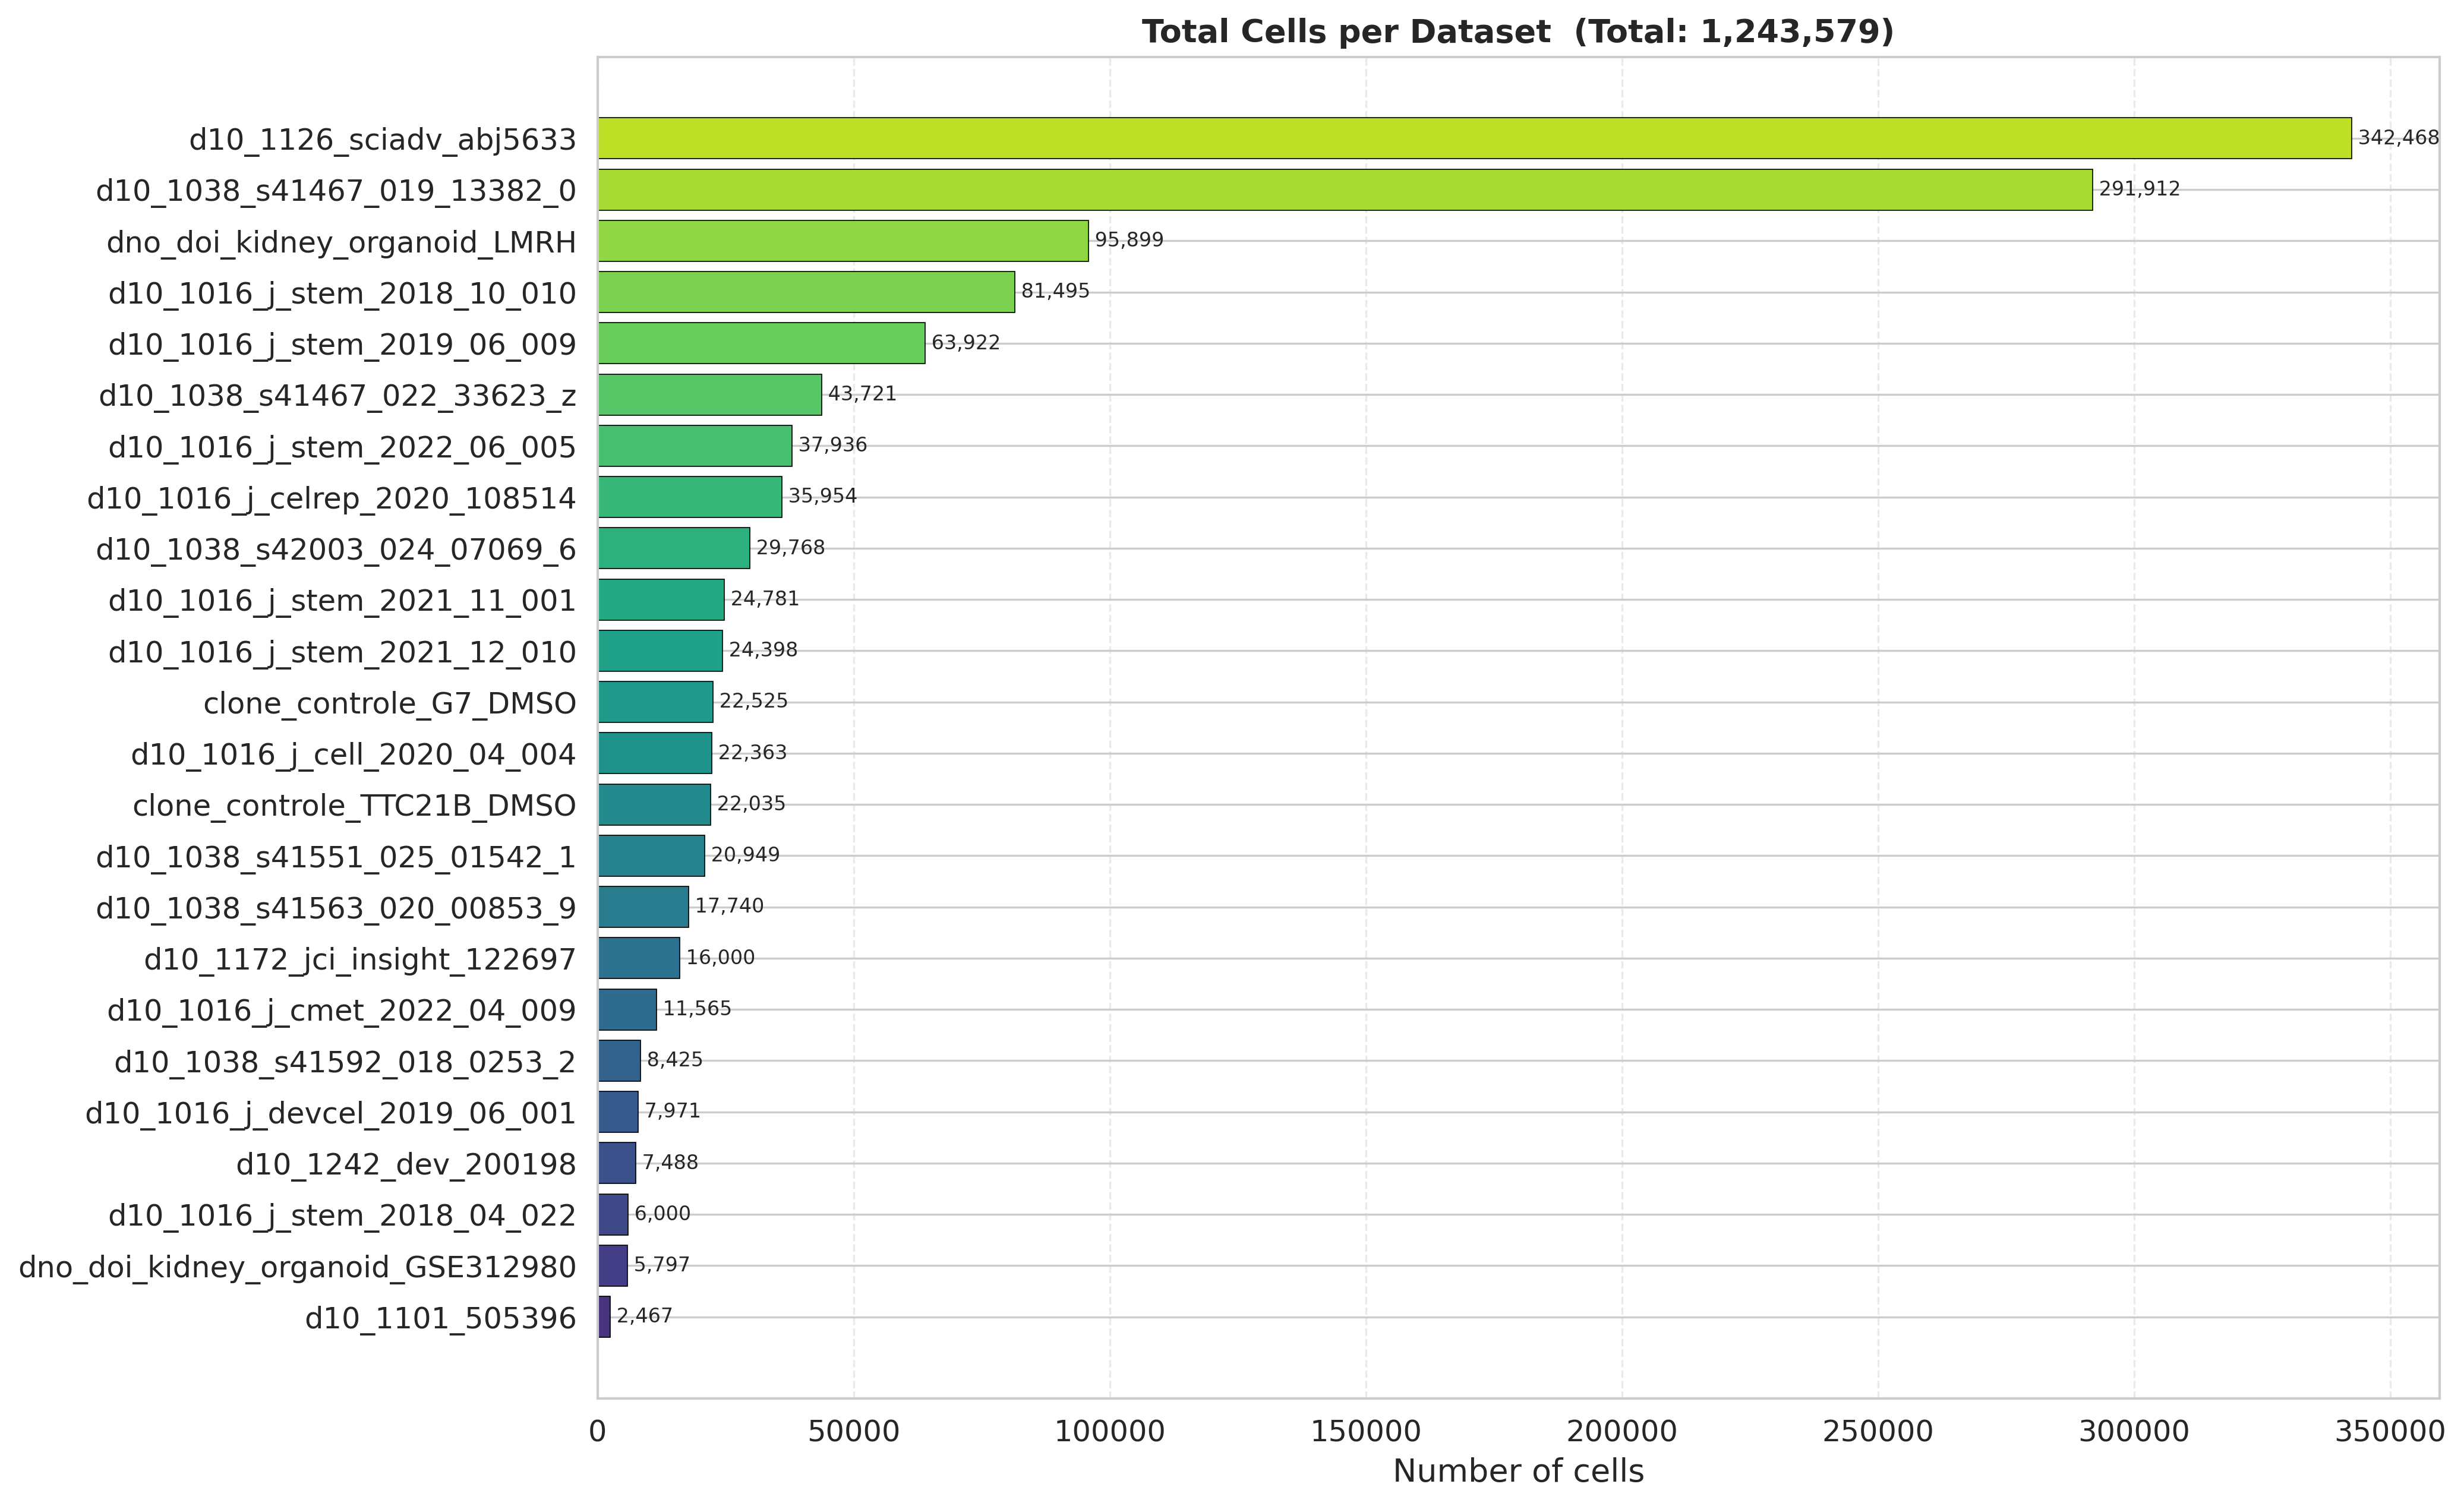

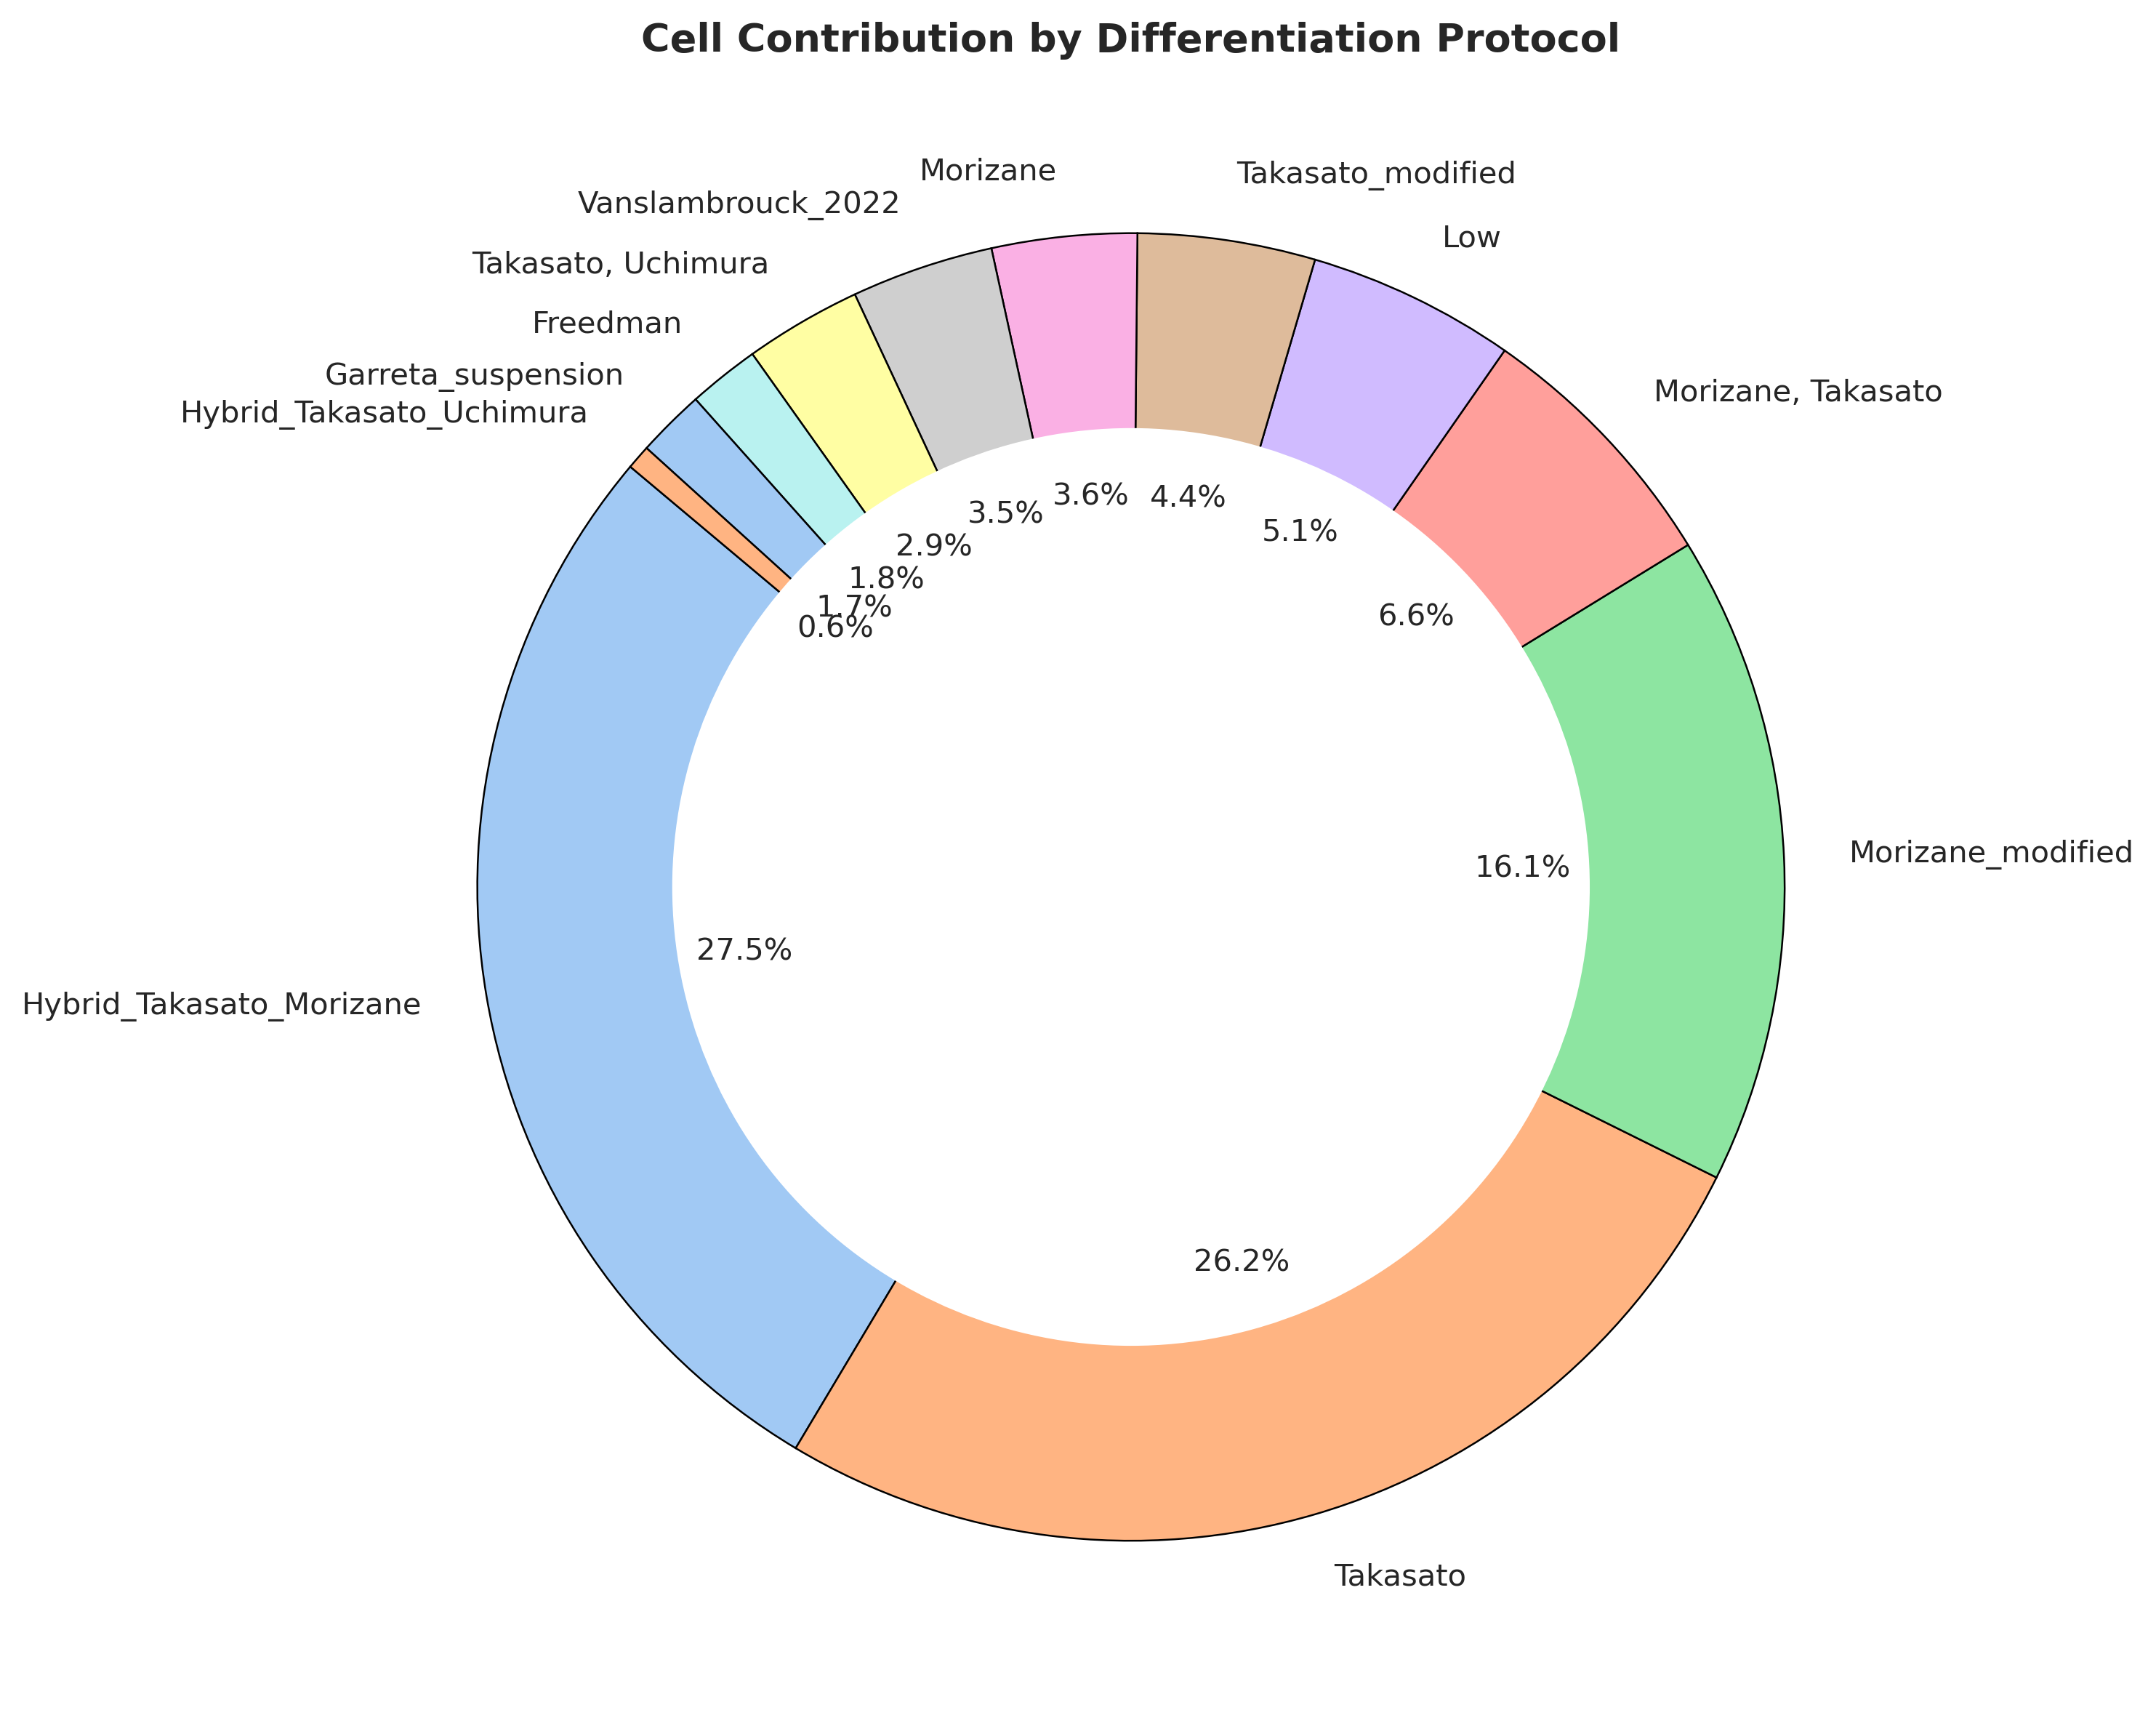

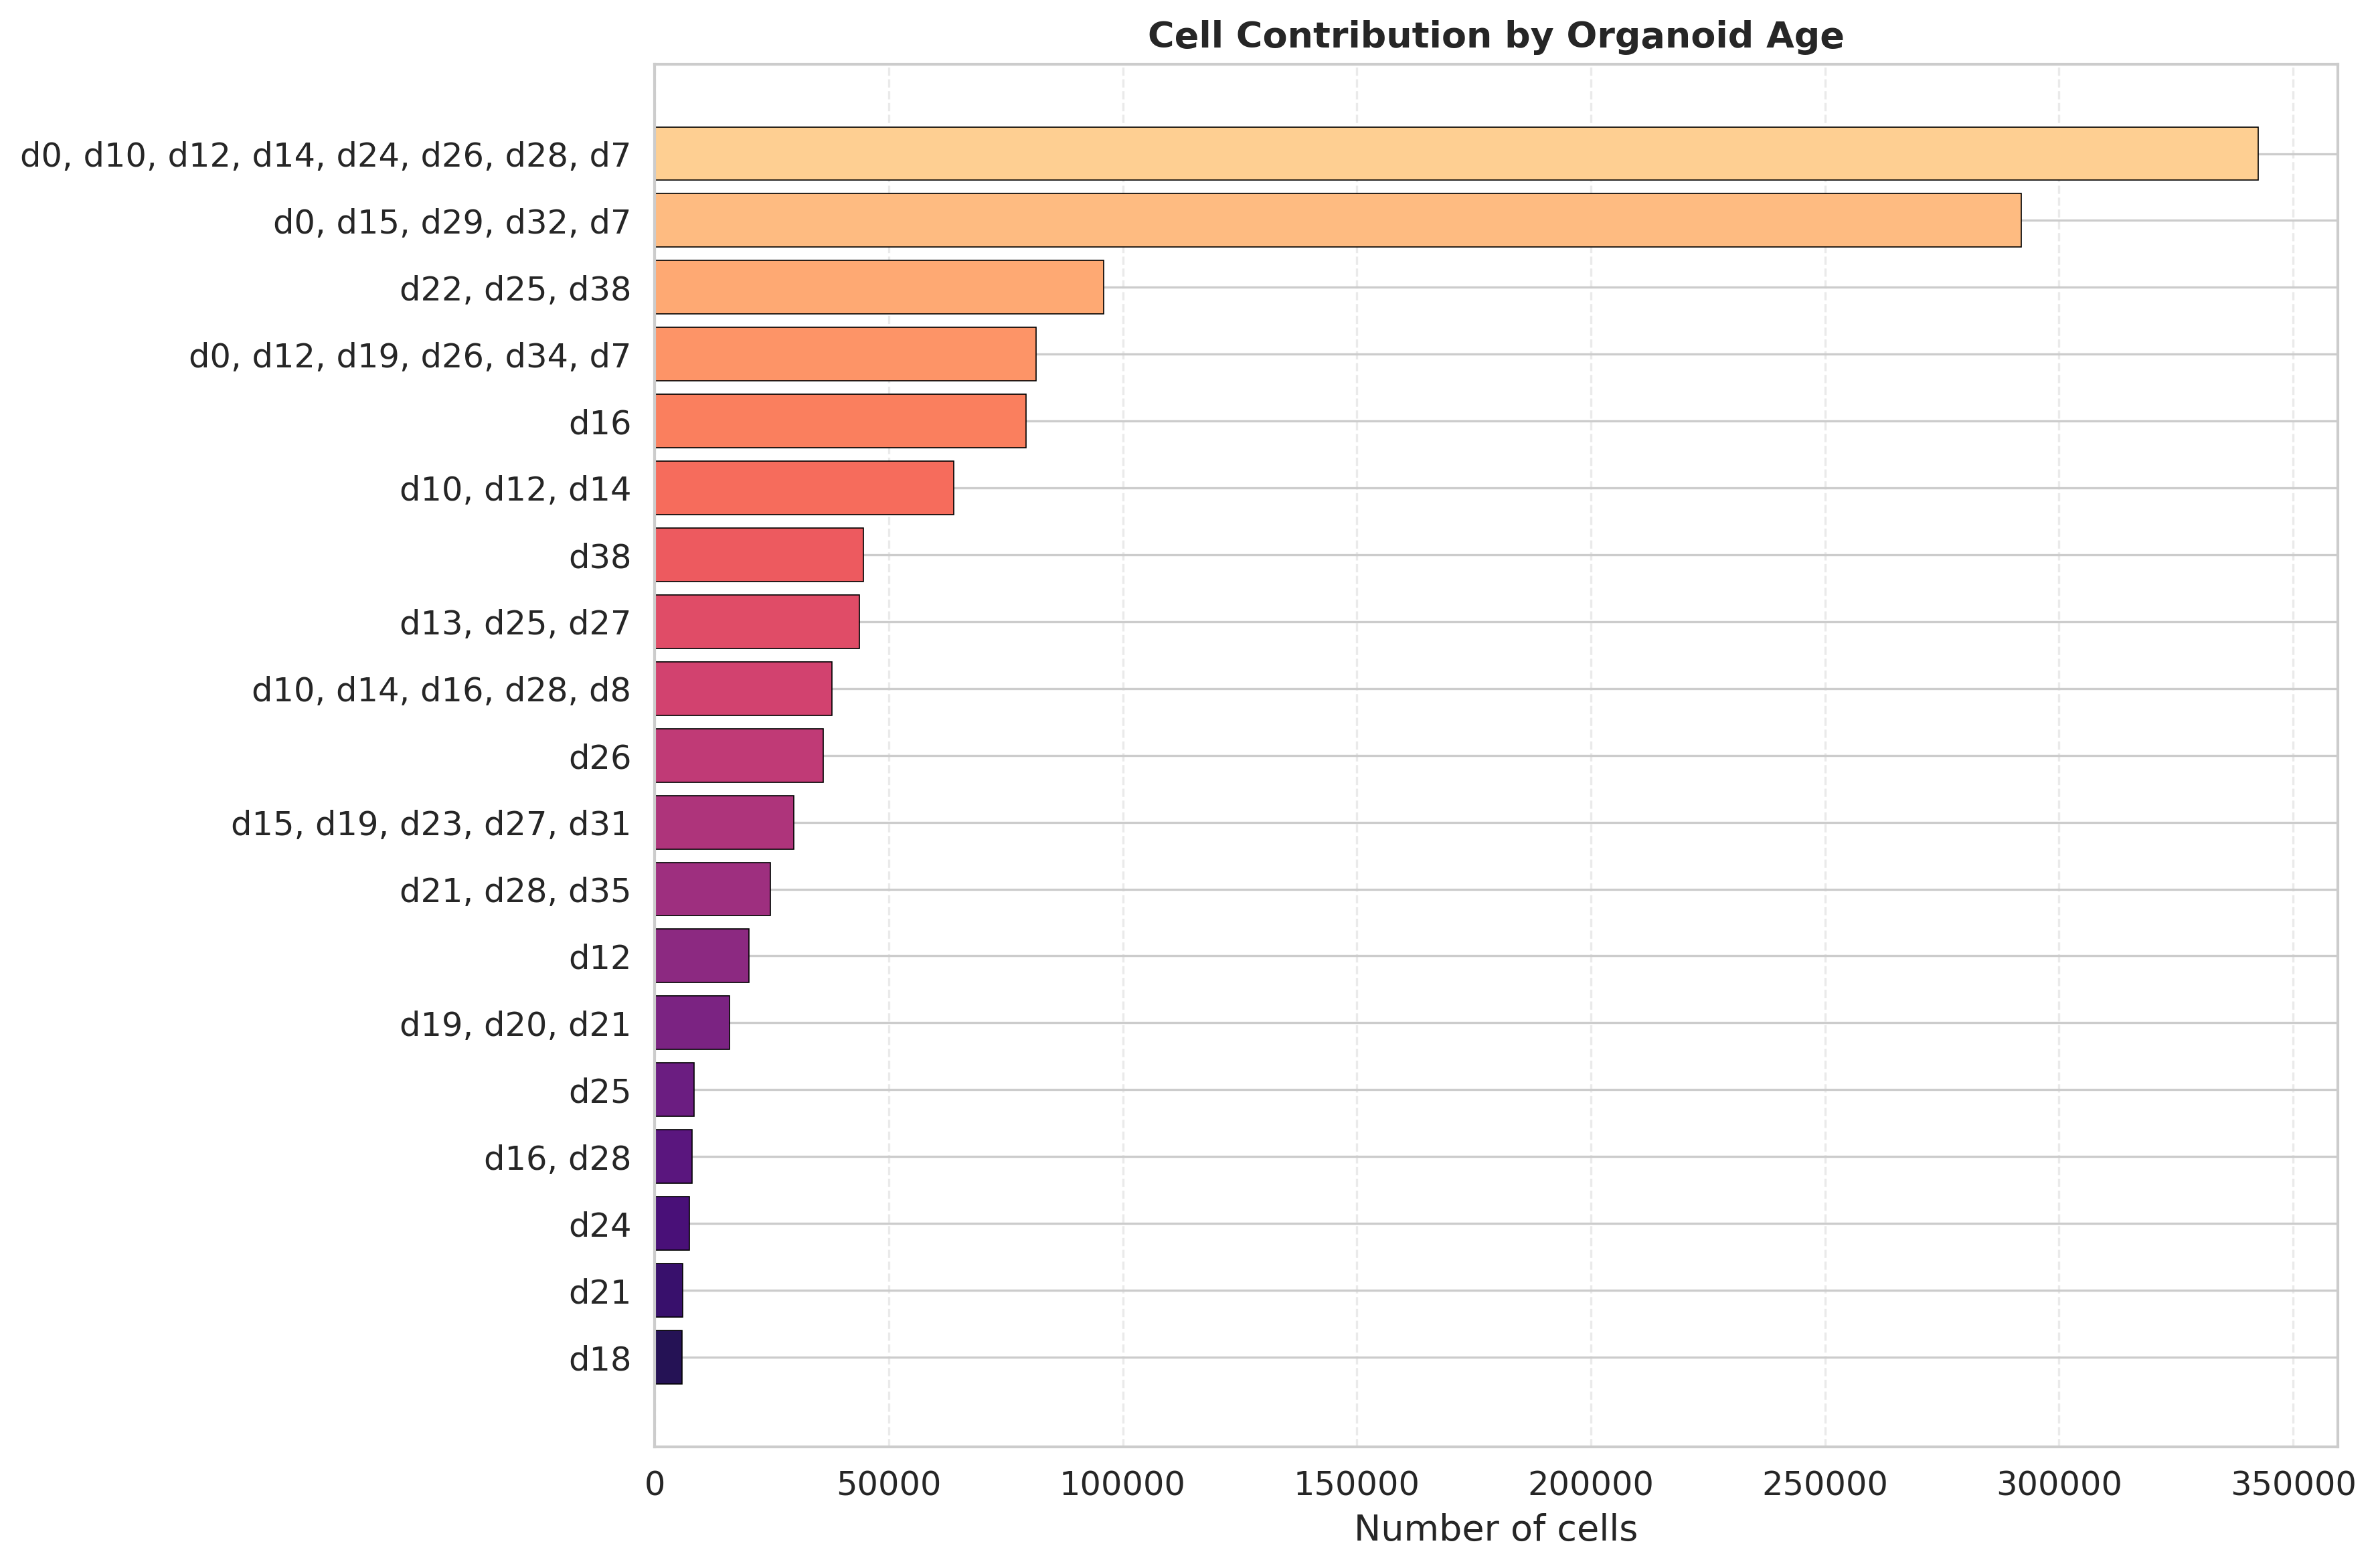


Report saved to: /data-master/pure-workspace/labss/hmami/new_data/reports/atlas_summary/


In [110]:
import os
import glob
import numpy as np
import pandas as pd
import scanpy as sc  # <-- This re-establishes 'sc' as the scanpy module
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='paper', font_scale=1.35)
plt.rcParams.update({'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'})

REPORT_DIR = os.path.join(os.path.dirname(DATA_ROOT), 'reports', 'atlas_summary')
os.makedirs(REPORT_DIR, exist_ok=True)

def scan_and_summarize_atlas(harmonized_dir: str) -> pd.DataFrame:
    """Scan all harmonised .h5ad files and compile a dataset-level summary."""
    h5ad_files = glob.glob(os.path.join(harmonized_dir, '*_harmonized.h5ad'))
    rows = []
    print(f'Scanning {len(h5ad_files)} harmonised files...')
    for fpath in sorted(h5ad_files):
        try:
            ad = sc.read_h5ad(fpath, backed='r')

            def _get(col):
                if col not in ad.obs.columns:
                    return 'unknown'
                vals = [v for v in ad.obs[col].unique() if pd.notna(v) and str(v) != 'nan']
                return vals[0] if len(vals) == 1 else (', '.join(sorted(map(str, vals))) if vals else 'unknown')

            rows.append({
                'File':      os.path.basename(fpath),
                'Study':     _get('study'),
                'Cells':     int(ad.n_obs),
                'Genes':     int(ad.n_vars),
                'Protocol':  _get('diff_protocol'),
                'Age':       _get('Age'),
                'Tech':      _get('sc_protocol'),
                'Source':    _get('source'),
                'Disease':   _get('disease'),
                'Condition': _get('condition'),
            })
        except Exception as e:
            print(f'  Skipping {os.path.basename(fpath)}: {e}')
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values('Cells', ascending=False).reset_index(drop=True)
    return df

df_summary = scan_and_summarize_atlas(HARMONIZED_DIR)
csv_path   = os.path.join(REPORT_DIR, 'dataset_summary.csv')
df_summary.to_csv(csv_path, index=False)
print(f'\nSaved summary table → {csv_path}')

total_cells = int(df_summary['Cells'].sum())
print(f'\nATLAS SUMMARY  ({len(df_summary)} datasets, {total_cells:,} total cells)')
print(df_summary[['Study', 'Cells', 'Genes', 'Protocol', 'Age', 'Tech']].to_string(index=False))

# ── Plot 1: cells per dataset ──────────────────────────────────────────────────
plot_data = df_summary.sort_values('Cells', ascending=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(plot_data)))
fig, ax = plt.subplots(figsize=(14, max(6, 0.36 * len(plot_data))))
ax.barh(plot_data['Study'], plot_data['Cells'], color=colors, edgecolor='black', linewidth=0.4)
ax.set_title(f'Total Cells per Dataset  (Total: {total_cells:,})', fontweight='bold')
ax.set_xlabel('Number of cells')
for y, v in enumerate(plot_data['Cells'].values):
    ax.text(v, y, f' {v:,}', va='center', fontsize=8)
ax.grid(axis='x', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(REPORT_DIR, 'cells_per_dataset.png'))
fig.savefig(os.path.join(REPORT_DIR, 'cells_per_dataset.pdf'))
plt.show()

# ── Plot 2: cells by differentiation protocol ─────────────────────────────────
proto_counts = df_summary.groupby('Protocol')['Cells'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    proto_counts.values, labels=proto_counts.index, autopct='%1.1f%%',
    startangle=140, colors=sns.color_palette('pastel', n_colors=len(proto_counts)),
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.6}, textprops={'fontsize': 10})
ax.add_artist(plt.Circle((0, 0), 0.70, fc='white'))
ax.set_title('Cell Contribution by Differentiation Protocol', fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(REPORT_DIR, 'cells_by_protocol.png'))
fig.savefig(os.path.join(REPORT_DIR, 'cells_by_protocol.pdf'))
plt.show()

# ── Plot 3: cells by organoid age ─────────────────────────────────────────────
age_counts = df_summary.groupby('Age')['Cells'].sum().sort_values(ascending=False).head(20)
colors2 = plt.cm.magma(np.linspace(0.15, 0.9, len(age_counts)))
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(age_counts.index[::-1], age_counts.values[::-1], color=colors2, edgecolor='black', linewidth=0.4)
ax.set_title('Cell Contribution by Organoid Age', fontweight='bold')
ax.set_xlabel('Number of cells')
ax.grid(axis='x', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(REPORT_DIR, 'cells_by_age.png'))
fig.savefig(os.path.join(REPORT_DIR, 'cells_by_age.pdf'))
plt.show()

print(f'\nReport saved to: {REPORT_DIR}/')

Scanning and extracting all sub-samples/timepoints across 24 files...

Color assignments:
  Freedman: #275000
  Garreta_suspension: #e52d2d
  Hybrid_Takasato_Morizane: #800080
  Hybrid_Takasato_Uchimura: #FFA500
  Low: #2d63e5
  Morizane: #87CEEB
  Takasato: #FF0000
  Uchimura: #99e52d
  Vanslambrouck_2022: #e52dce


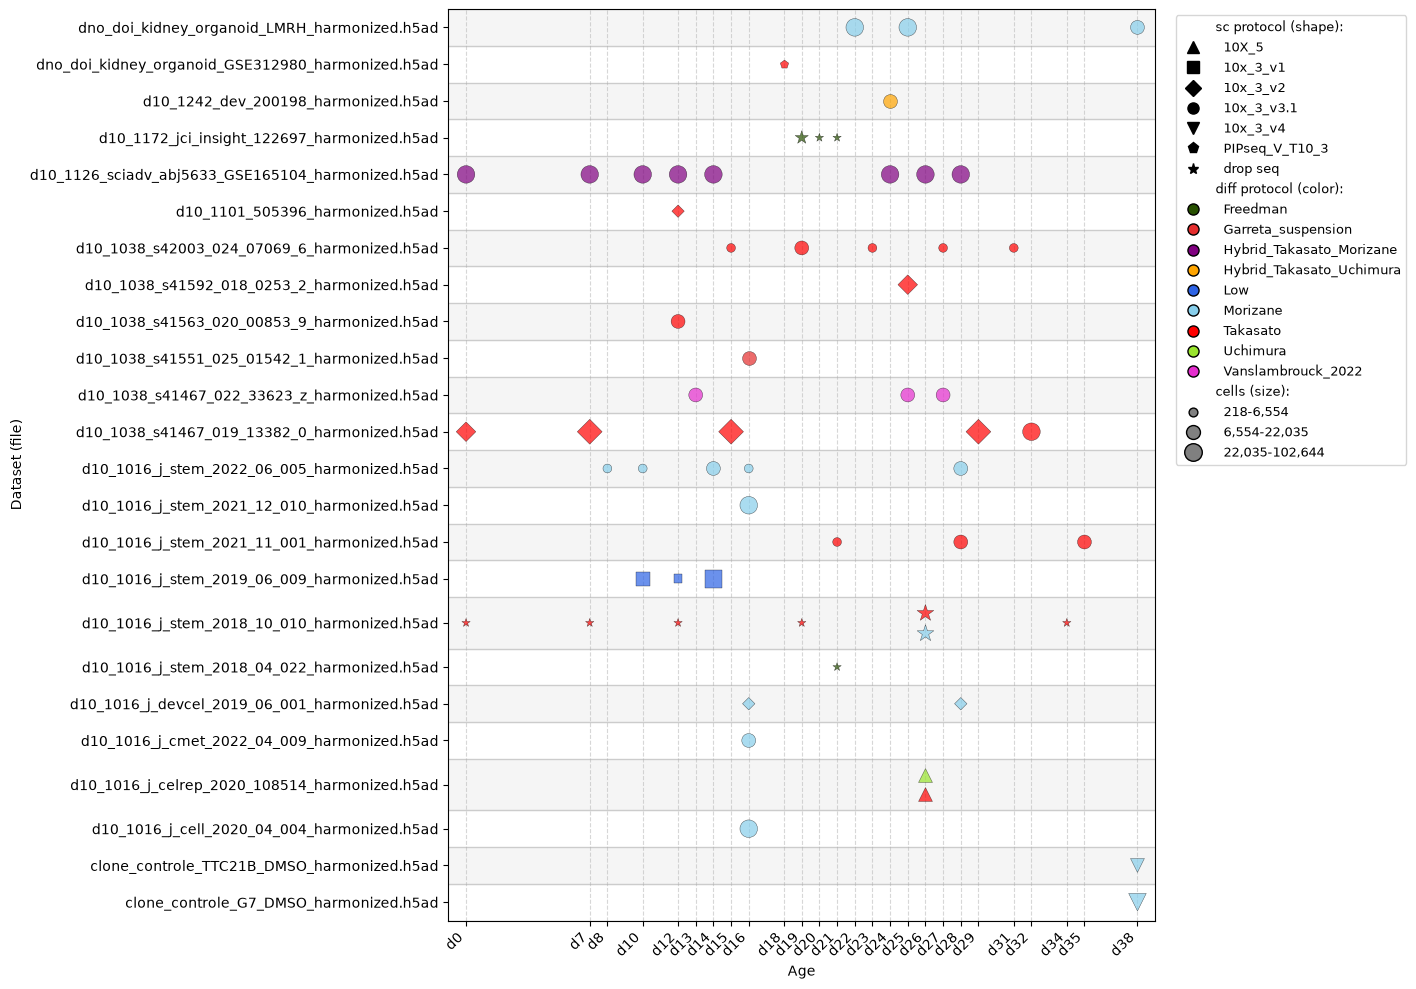

In [1]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import h5py

# ---------------------------------------------------------
# 0. CONFIGURATION & DIRECTORY SETUP
# ---------------------------------------------------------
DATA_DIR = Path("/data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files")
h5ad_files = sorted(list(DATA_DIR.glob("*.h5ad")))

if not h5ad_files:
    raise FileNotFoundError(f"No .h5ad files found in {DATA_DIR}")

# Metadata column layout inside .obs
selected_meta_cols = {
    'differentiation_protocol': 'diff_protocol', 
    'sc_protocol': 'sc_protocol',
    'age': 'Age'
}

use_numeric_age = True      
unknown_age_value = -1      
age_order = None            

# ---------------------------------------------------------
# 1. FULL-COLUMN HDF5 ARRAY EXTRACTOR & CLEANER
# ---------------------------------------------------------
print(f"Scanning and extracting all sub-samples/timepoints across {len(h5ad_files)} files...")

def clean_age_value(val):
    """
    Extracts numerical digits from mixed age formats (e.g., 'd7' -> 7.0, 'Day 10' -> 10.0).
    Returns np.nan if the value cannot be parsed into a number.
    """
    if pd.isna(val) or str(val).strip() in ['nan', 'None', 'Unknown']:
        return np.nan
    
    v_str = str(val).strip()
    # Find any integer or decimal number inside the string
    match = re.search(r"[-+]?\d*\.\d+|\d+", v_str)
    if match:
        return float(match.group())
    return np.nan

def read_obs_column(obs_group, key):
    """
    Extracts an entire column array from the HDF5 obs group, unpacking
    standard datasets, categorical structures, or nested nullable array groups.
    """
    if key not in obs_group:
        return None
    item = obs_group[key]
    
    # Scenario A: Anndata Categorical Group
    if isinstance(item, h5py.Group) and 'codes' in item and 'categories' in item:
        codes = item['codes'][:]
        categories = item['categories'][:]
        cats = [c.decode('utf-8') if isinstance(c, bytes) else c for c in categories]
        res = [cats[c] if 0 <= c < len(cats) else np.nan for c in codes]
        return np.array(res, dtype=object)
        
    # Scenario B: Modern Nullable Array Group (contains data & mask)
    elif isinstance(item, h5py.Group) and 'data' in item:
        data_item = item['data']
        arr = data_item[:] if isinstance(data_item, h5py.Dataset) else None
        if arr is None:
            return None
        if arr.dtype.kind in ['S', 'O', 'U']:
            arr = np.array([v.decode('utf-8') if isinstance(v, bytes) else v for v in arr], dtype=object)
        if 'mask' in item:
            mask = item['mask'][:]
            arr = np.where(mask, np.nan, arr)
        return arr
        
    # Scenario C: Standard Flat Dataset Array
    elif isinstance(item, h5py.Dataset):
        arr = item[:]
        if arr.dtype.kind in ['S', 'O', 'U']:
            arr = np.array([v.decode('utf-8') if isinstance(v, bytes) else v for v in arr], dtype=object)
        return arr
        
    return None

def normalize_value_single(group: str, value: str) -> str:
    v = str(value).strip()
    key = re.sub(r'[\s\-]+', '_', v.lower())
    if group == 'differentiation_protocol':
        mapping = {
            'morizane': 'Morizane',
            'morizane_modified': 'Morizane',
            'takasato': 'Takasato',
            'takasato_2016': 'Takasato',
            'takasato_modified': 'Takasato',
            'hybrid_takasato_morizane': 'Hybrid_Takasato_Morizane',
            'hybrid_takasato_uchimura': 'Hybrid_Takasato_Uchimura'
        }
        return mapping.get(key, v)
    if group == 'sc_protocol':
        mapping = {
            '10x_3_v3': '10x_3_v3.1',
            '10x_v2': '10x_3_v2',
            'drop_seq': 'drop seq',
            'dropseq': 'drop seq'
        }
        return mapping.get(key, v)
    return v

plot_rows = []

for path in h5ad_files:
    file_name = path.name
    try:
        with h5py.File(path, 'r') as f:
            if 'obs' not in f:
                continue
            obs_g = f['obs']
            
            age_arr = read_obs_column(obs_g, selected_meta_cols['age'])
            diff_arr = read_obs_column(obs_g, selected_meta_cols['differentiation_protocol'])
            sc_arr = read_obs_column(obs_g, selected_meta_cols['sc_protocol'])
            
            length = 0
            for arr in [age_arr, diff_arr, sc_arr]:
                if arr is not None:
                    length = len(arr)
                    break
            if length == 0:
                continue
                
            if age_arr is None: age_arr = np.full(length, np.nan, dtype=object)
            if diff_arr is None: diff_arr = np.full(length, 'Unknown', dtype=object)
            if sc_arr is None: sc_arr = np.full(length, 'Unknown', dtype=object)
            
            df_temp = pd.DataFrame({'age': age_arr, 'diff': diff_arr, 'sc': sc_arr}).fillna(np.nan)
            counts = df_temp.groupby(['age', 'diff', 'sc'], dropna=False).size().reset_index(name='cell_count')
            
            for _, row in counts.iterrows():
                # Apply the numerical digit extraction fix right here
                age_val = clean_age_value(row['age']) 
                diff_val = row['diff']
                sc_val = row['sc']
                cell_count = int(row['cell_count'])
                
                if pd.isna(age_val):
                    continue
                    
                if pd.isna(diff_val) or str(diff_val) in ['nan', 'None']:
                    diff_val = 'Unknown'
                if pd.isna(sc_val) or str(sc_val) in ['nan', 'None']:
                    sc_val = 'Unknown'
                    
                plot_rows.append({
                    'file': file_name,
                    'age_x': age_val,
                    'diff_protocol': normalize_value_single('differentiation_protocol', diff_val),
                    'sc_protocol': normalize_value_single('sc_protocol', sc_val),
                    'n_cells': cell_count
                })
    except Exception as e:
        print(f"Warning: Skipping file {file_name} due to matrix error: {e}")

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError('No valid data points found. Double check your column headers.')

file_order = sorted(plot_df['file'].unique())

# ---------------------------------------------------------
# 2. DYNAMIC ZONE SIZING BASED ON SAMPLE OVERLAP
# ---------------------------------------------------------
file_y_info = {}
current_bottom = 0.0

for f in file_order:
    df_file = plot_df[plot_df['file'] == f]
    max_overlap = df_file.groupby('age_x').size().max() if not df_file.empty else 1
    height = max(1.0, 1.0 + (max_overlap - 1) * 0.4)
    
    center = current_bottom + (height / 2.0)
    top = current_bottom + height
    
    file_y_info[f] = {
        'center': center,
        'bottom': current_bottom,
        'top': top,
        'height': height
    }
    current_bottom = top

# ---------------------------------------------------------
# 3. APPLY Y-COORDINATES & SWARM JITTER
# ---------------------------------------------------------
plot_df['y_pos'] = plot_df['file'].map(lambda x: file_y_info[x]['center'] if x in file_y_info else 0)

for (f, age), group in plot_df.groupby(['file', 'age_x']):
    n = len(group)
    if n > 1:
        zone_height = file_y_info[f]['height']
        spread = zone_height * 0.75 
        
        if n == 2:
            offsets = np.array([-spread/4, spread/4])
        else:
            offsets = np.linspace(-spread/2, spread/2, n)
            
        plot_df.loc[group.index, 'y_pos'] += offsets

# ---------------------------------------------------------
# 4. SCALE BUBBLE MARKER SIZES BASED ON SUB-SAMPLE SIZES
# ---------------------------------------------------------
min_size = 40
max_size = 160
sizes = plot_df['n_cells'].astype(float)
counts_nonzero = sizes[sizes > 0]

size_levels = np.linspace(min_size, max_size, 3)
size_levels = [float(round(s / 5) * 5) for s in size_levels]

if counts_nonzero.size > 0:
    q = np.quantile(counts_nonzero, [0.0, 1 / 3, 2 / 3, 1.0])
    bins = [float(q[0]), float(q[1]), float(q[2]), float(q[3])]
    for i in range(1, len(bins)):
        if bins[i] < bins[i - 1]:
            bins[i] = bins[i - 1]
    size_cat = pd.Series(np.digitize(sizes, bins[1:-1], right=True), index=plot_df.index)
    size_map = {0: size_levels[0], 1: size_levels[1], 2: size_levels[2]}
    plot_df['marker_size'] = size_cat.map(size_map)
else:
    bins = [0.0, 0.0, 0.0, 0.0]
    plot_df['marker_size'] = min_size

# ---------------------------------------------------------
# X-AXIS HANDLING: Continuous Timeline Math
# ---------------------------------------------------------
plot_df['age_x_plot'] = plot_df['age_x'].astype(float)
numeric_vals = sorted(plot_df['age_x_plot'].unique())

tickvals = numeric_vals
# Dynamic tick naming adds a 'd' prefix back cleanly to the layout (e.g., 7.0 -> 'd7')
ticktext = [f"d{int(v)}" if float(v).is_integer() else f"d{v}" for v in numeric_vals]

# ---------------------------------------------------------
# 5. GENERATE PLOT SCATTER MATRIX WITH CUSTOM COLORS
# ---------------------------------------------------------
sc_values = sorted(plot_df['sc_protocol'].astype(str).unique())
diff_values = sorted(plot_df['diff_protocol'].astype(str).unique())
marker_seq = ['^', 's', 'D', 'o', 'v', 'p', '*', 'X', 'h', 'P']
marker_map = {v: marker_seq[i % len(marker_seq)] for i, v in enumerate(sc_values)}

# --- CUSTOM COLOR MAPPING ---
# Define specific colors for key protocols
custom_colors = {
    'Morizane': '#87CEEB',  # Light blue
    'Takasato': '#FF0000', 
    'Freedman': "#275000",  # Red
    'Hybrid_Takasato_Morizane': '#800080',  # Purple
    'Hybrid_Takasato_Uchimura': '#FFA500',  # Orange
}

# Generate random colors for any remaining protocols
import random
random.seed(42)  # For reproducibility

# Get all protocols that don't have custom colors
remaining_protocols = [p for p in diff_values if p not in custom_colors]

# Generate distinct random colors for remaining protocols
def generate_distinct_colors(n):
    """Generate n distinct visually distinguishable colors."""
    colors = []
    # Use golden ratio to spread colors evenly in hue space
    golden_ratio = 0.618033988749895
    for i in range(n):
        hue = (i * golden_ratio) % 1.0
        # Convert HSV to RGB with high saturation and moderate value
        import colorsys
        rgb = colorsys.hsv_to_rgb(hue, 0.8, 0.9)
        colors.append(f'#{int(rgb[0]*255):02x}{int(rgb[1]*255):02x}{int(rgb[2]*255):02x}')
    return colors

# Add random colors for remaining protocols
if remaining_protocols:
    random_colors = generate_distinct_colors(len(remaining_protocols))
    for i, proto in enumerate(remaining_protocols):
        custom_colors[proto] = random_colors[i]

# Create final color map
color_map = {v: custom_colors.get(v, '#808080') for i, v in enumerate(diff_values)}

# Print color assignment for verification
print("\nColor assignments:")
for proto, color in color_map.items():
    print(f"  {proto}: {color}")

fig, ax = plt.subplots(figsize=(18, 10))
for sc in sc_values:
    for diff in diff_values:
        sub = plot_df[(plot_df['sc_protocol'] == sc) & (plot_df['diff_protocol'] == diff)]
        if sub.empty:
            continue
        ax.scatter(
            sub['age_x_plot'],
            sub['y_pos'],
            s=sub['marker_size'],
            marker=marker_map[sc],
            color=color_map[diff],
            edgecolor='black',
            linewidth=0.3,
            alpha=0.7,
            zorder=3
        )

# Dual-Legend Config Assembly
legend_elements = []
legend_elements.append(Line2D([0], [0], linestyle='None', color='none', label='sc protocol (shape):'))
for sc in sc_values:
    legend_elements.append(Line2D([0], [0], marker=marker_map[sc], linestyle='None',
                                  color='black', markeredgecolor='black', markersize=8,
                                  label=f"  {sc}"))
legend_elements.append(Line2D([0], [0], linestyle='None', color='none', label='diff protocol (color):'))
for diff in diff_values:
    legend_elements.append(Line2D([0], [0], marker='o', linestyle='None',
                                  color=color_map[diff], markeredgecolor='black', markersize=8,
                                  label=f"  {diff}"))
legend_elements.append(Line2D([0], [0], linestyle='None', color='none', label='cells (size):'))
for i in range(3):
    lo = bins[i]
    hi = bins[i + 1]
    label = f"{int(lo):,}-{int(hi):,}"
    legend_elements.append(Line2D([0], [0], marker='o', linestyle='None',
                                  color='gray', markeredgecolor='black',
                                  markersize=max(4, np.sqrt(size_levels[i])), label=f"  {label}"))

# ---------------------------------------------------------
# 6. DYNAMIC AXES FORMATTING
# ---------------------------------------------------------
y_ticks = [file_y_info[f]['center'] for f in file_order if f in file_y_info]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f for f in file_order if f in file_y_info])

for i, f in enumerate(file_order):
    if f not in file_y_info:
        continue
    info = file_y_info[f]
    zone_color = '#ffffff' if i % 2 == 0 else '#f5f5f5'
    ax.axhspan(info['bottom'], info['top'], color=zone_color, zorder=0)
    ax.axhline(info['bottom'], color='#cccccc', linewidth=1, zorder=1)

ax.axhline(current_bottom, color='#cccccc', linewidth=1, zorder=1)

ax.set_xlabel('Age')
ax.set_ylabel('Dataset (file)')
ax.set_xticks(tickvals)
ax.set_xticklabels(ticktext, rotation=45, ha='right')

# Use actual numeric boundaries for perfectly scaled grid dimensions
ax.set_xlim(min(tickvals) - 1, max(tickvals) + 1)
ax.set_ylim(0, current_bottom)
ax.margins(y=0) 
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=2)

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
          frameon=True, fontsize=9)
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

In [79]:
# ── Batch Conversion of Harmonized .h5ad to Seurat .rds ───────────────────────
import os, glob, gc
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp

# R and conversion imports
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import anndata2ri

pandas2ri.activate()
import warnings
warnings.filterwarnings("ignore", message="Observation names are not unique.*")

# Setup RDS output directory in the new Updated_data folder
OUTPUT_ROOT = os.path.join(os.path.dirname(DATA_ROOT), "Updated_data")
RDS_DIR = os.path.join(OUTPUT_ROOT, "updated_rds_files")
os.makedirs(RDS_DIR, exist_ok=True)

# List of expected columns from the harmonization pipeline
EXPECTED_COLS = [
    'sample_id', 'study', 'source', 'diff_protocol', 'sc_protocol',
    'sequencing', 'genome_build', 'Age', 'type', 'disease', 'condition'
]

# 1. Setup R Environment
ro.r('''
    message("Loading R libraries...")
    if (!require("BiocManager", quietly = TRUE))
        install.packages("BiocManager", repos="http://cran.us.r-project.org")
    if (!require("SingleCellExperiment", quietly = TRUE))
        BiocManager::install("SingleCellExperiment", update = FALSE, ask = FALSE)
    
    suppressPackageStartupMessages(library(Seurat))
    suppressPackageStartupMessages(library(SingleCellExperiment))
    suppressPackageStartupMessages(library(Matrix))
''')

# 2. Discover files (using the updated HARMONIZED_DIR)
h5ad_files = sorted(glob.glob(os.path.join(HARMONIZED_DIR, '*_harmonized.h5ad')))
print(f"Found {len(h5ad_files)} harmonized .h5ad files to convert.")

# 3. Process each file
for file_path in h5ad_files:
    fname = os.path.basename(file_path)
    stem = fname.replace('.h5ad', '')
    output_rds = os.path.join(RDS_DIR, f"{stem}.rds")
    
    print(f"\n{'='*80}")
    print(f"Processing: {fname}")
    
    if os.path.exists(output_rds):
        print(f"  [!] Skipping: {os.path.basename(output_rds)} already exists.")
        continue

    # --- SANITY CHECK & PREVIEW ---
    print("  -> Performing Sanity Check & Preview...")
    try:
        # Load in backed mode just to check structure without full RAM load
        chk_adata = sc.read_h5ad(file_path, backed='r')
        
        if chk_adata.n_obs == 0 or chk_adata.n_vars == 0:
            print("  [❌] FAILED: Matrix is empty (0 cells or 0 genes). Skipping.")
            continue
            
        missing_cols = [col for col in EXPECTED_COLS if col not in chk_adata.obs.columns]
        if missing_cols:
            print(f"  [❌] FAILED: Missing required metadata columns: {missing_cols}. Skipping.")
            continue
            
        # Warn for non-unique indices (fixed automatically during conversion)
        if not chk_adata.obs_names.is_unique or not chk_adata.var_names.is_unique:
            print("  [!] WARNING: Indices are not unique (will be fixed automatically).")
            
        # PREVIEW THE FIRST 5 LINES
        print("\n--- Metadata Preview (First 5 Cells) ---")
        print(chk_adata.obs[EXPECTED_COLS].head(5).to_string())
        print("----------------------------------------\n")
        
        del chk_adata
    except Exception as e:
        print(f"  [❌] FAILED: File appears corrupted or unreadable. Error: {e}")
        continue
    
    # --- CONVERSION ---
    print("  -> Loading full matrix to memory...")
    try:
        adata = sc.read_h5ad(file_path)
        
        # Sanitize Indices
        adata.obs.index = adata.obs.index.astype(str)
        adata.var.index = adata.var.index.astype(str)
        if not adata.obs.index.is_unique: adata.obs_names_make_unique()
        if not adata.var.index.is_unique: adata.var_names_make_unique()

        # Sanitize Metadata (force to string to prevent R categorization/factor issues)
        print("  -> Sanitizing metadata...")
        obs_clean = pd.DataFrame(index=adata.obs.index)
        for col in adata.obs.columns:
            obs_clean[col] = adata.obs[col].astype(str)
            
        var_clean = pd.DataFrame(index=adata.var.index)
        for col in adata.var.columns:
            var_clean[col] = adata.var[col].astype(str)

        # Sanitize Matrix (float64 is critical for reliable rpy2 sparse matrix transfer)
        print("  -> Converting sparse matrix to float64...")
        if sp.issparse(adata.X):
            X_clean = adata.X.tocsr().astype('float64')
        else:
            X_clean = sp.csr_matrix(adata.X).astype('float64')

        if np.isnan(X_clean.data).any():
            print("  [!] WARNING: NaNs detected in count matrix. Replacing with 0.")
            X_clean.data = np.nan_to_num(X_clean.data, nan=0.0)

        # Create Minimal AnnData
        clean_adata = sc.AnnData(X=X_clean, obs=obs_clean, var=var_clean)

        # Push to R Environment
        print("  -> Pushing object to R environment...")
        with ro.conversion.localconverter(anndata2ri.converter):
            ro.globalenv["adata_sce"] = clean_adata

        # R Seurat Construction
        print("  -> Building Seurat object and saving...")
        ro.r(f'''
            tryCatch({{
                # Extract matrix directly from SCE object to bypass as.Seurat layer bugs
                counts_mat <- SummarizedExperiment::assay(adata_sce, 1)
                
                if (Matrix::nnzero(counts_mat) == 0) {{
                    stop("Count matrix has zero non-zero entries after SCE extraction.")
                }}

                # Build clean Seurat Object
                seurat_obj <- CreateSeuratObject(counts = counts_mat, assay = "RNA")
                
                # Append string metadata
                if (ncol(colData(adata_sce)) > 0) {{
                    seurat_obj[[]] <- as.data.frame(colData(adata_sce))
                }}

                # Explicitly compute and inject QC metrics
                seurat_obj[["nCount_RNA"]] <- Matrix::colSums(counts_mat)
                seurat_obj[["nFeature_RNA"]] <- Matrix::colSums(counts_mat > 0)

                # Validation
                na_ncount <- sum(is.na(seurat_obj$nCount_RNA))
                na_nfeature <- sum(is.na(seurat_obj$nFeature_RNA))
                if (na_ncount > 0 || na_nfeature > 0) {{
                    stop(sprintf("Validation failed: nCount_RNA=%d NAs | nFeature_RNA=%d NAs", na_ncount, na_nfeature))
                }}

                # Save Object
                saveRDS(seurat_obj, file = "{output_rds}")
            }}, error = function(e) {{
                message(paste("ERROR in R:", e$message))
                stop(e)
            }})
        ''')
        
        print(f"  ✅ SUCCESS: Saved {os.path.basename(output_rds)}")

    except Exception as e:
        print(f"  ❌ FAIL: {e}")

    finally:
        # Strict memory cleanup to avoid Jupyter crashes
        for var_name in ['adata', 'clean_adata', 'X_clean', 'obs_clean', 'var_clean']:
            if var_name in locals():
                del locals()[var_name]
        try:
            ro.r('''
                if (exists("adata_sce")) rm(adata_sce)
                if (exists("counts_mat")) rm(counts_mat)
                if (exists("seurat_obj")) rm(seurat_obj)
                gc()
            ''')
        except Exception:
            pass
        gc.collect()

print("\n🎉 Script complete!")

R[write to console]: Loading R libraries...



Found 24 harmonized .h5ad files to convert.

Processing: clone_controle_G7_DMSO_harmonized.h5ad
  -> Performing Sanity Check & Preview...

--- Metadata Preview (First 5 Cells) ---
                   sample_id                   study source diff_protocol sc_protocol           sequencing genome_build  Age      type  disease condition
AAACCAAAGCAATCCA-1   G7_DMSO  clone_controle_G7_DMSO  hiPSC      Morizane    10x_3_v4  Illumina_HiSeq_2500         hg38  d38  scRNAseq  Control      DMSO
AAACCAAAGCCAGGTT-1   G7_DMSO  clone_controle_G7_DMSO  hiPSC      Morizane    10x_3_v4  Illumina_HiSeq_2500         hg38  d38  scRNAseq  Control      DMSO
AAACCAAAGCTATGTG-1   G7_DMSO  clone_controle_G7_DMSO  hiPSC      Morizane    10x_3_v4  Illumina_HiSeq_2500         hg38  d38  scRNAseq  Control      DMSO
AAACCAAAGCTTAGAT-1   G7_DMSO  clone_controle_G7_DMSO  hiPSC      Morizane    10x_3_v4  Illumina_HiSeq_2500         hg38  d38  scRNAseq  Control      DMSO
AAACCAAAGGCTTGGT-1   G7_DMSO  clone_controle_G7_DM

In [19]:
# ── Batch Conversion of Harmonized .h5ad to Seurat .rds ───────────────────────
import os, glob, gc
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp

# R and conversion imports
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import anndata2ri

pandas2ri.activate()
import warnings
warnings.filterwarnings("ignore", message="Observation names are not unique.*")

# Setup RDS output directory in the new Updated_data folder
OUTPUT_ROOT = os.path.join(os.path.dirname(DATA_ROOT), "Updated_data")
RDS_DIR = os.path.join(OUTPUT_ROOT, "updated_rds_files")
os.makedirs(RDS_DIR, exist_ok=True)

# List of expected columns from the harmonization pipeline
EXPECTED_COLS = [
    'sample_id', 'study', 'source', 'diff_protocol', 'sc_protocol',
    'sequencing', 'genome_build', 'Age', 'type', 'disease', 'condition'
]

# 1. Setup R Environment
ro.r('''
    message("Loading R libraries...")
    if (!require("BiocManager", quietly = TRUE))
        install.packages("BiocManager", repos="http://cran.us.r-project.org")
    if (!require("SingleCellExperiment", quietly = TRUE))
        BiocManager::install("SingleCellExperiment", update = FALSE, ask = FALSE)
    
    suppressPackageStartupMessages(library(Seurat))
    suppressPackageStartupMessages(library(SingleCellExperiment))
    suppressPackageStartupMessages(library(Matrix))
''')

# 2. Define input file (CHANGE THIS TO YOUR FILE)
INPUT_FILE = "/data-master/pure-workspace/labss/hmami/new_data/Updated_data/updated_harmonized_files/dno_doi_kidney_organoid_LMRH_harmonized.h5ad"  # CHANGE THIS

# 3. Process single file
file_path = INPUT_FILE
fname = os.path.basename(file_path)
stem = fname.replace('.h5ad', '')
output_rds = os.path.join(RDS_DIR, f"{stem}.rds")

print(f"\n{'='*80}")
print(f"Processing: {fname}")

if os.path.exists(output_rds):
    print(f"  [!] Skipping: {os.path.basename(output_rds)} already exists.")
else:
    # --- SANITY CHECK & PREVIEW ---
    print("  -> Performing Sanity Check & Preview...")
    try:
        # Load in backed mode just to check structure without full RAM load
        chk_adata = sc.read_h5ad(file_path, backed='r')
        
        if chk_adata.n_obs == 0 or chk_adata.n_vars == 0:
            print("  [❌] FAILED: Matrix is empty (0 cells or 0 genes). Skipping.")
        else:
            # Check for missing columns and add them if needed
            missing_cols = [col for col in EXPECTED_COLS if col not in chk_adata.obs.columns]
            if missing_cols:
                print(f"  [!] Missing metadata columns: {missing_cols}. Adding them...")
                # Close backed mode before modifying
                del chk_adata
                
                # Load full object to add missing columns
                adata_fix = sc.read_h5ad(file_path)
                
                # Add missing columns with default values
                for col in missing_cols:
                    if col == 'condition':
                        adata_fix.obs[col] = 'control'
                    else:
                        adata_fix.obs[col] = 'unknown'
                    print(f"    -> Added column '{col}' with default value: {'control' if col == 'condition' else 'unknown'}")
                
                # Save the fixed file (overwrite)
                adata_fix.write_h5ad(file_path)
                print(f"  ✅ Fixed file saved with missing columns added.")
                
                # Reload in backed mode for preview
                chk_adata = sc.read_h5ad(file_path, backed='r')
                missing_cols = [col for col in EXPECTED_COLS if col not in chk_adata.obs.columns]
                
            if missing_cols:
                print(f"  [❌] FAILED: Still missing required metadata columns: {missing_cols}. Skipping.")
            else:
                # Warn for non-unique indices (fixed automatically during conversion)
                if not chk_adata.obs_names.is_unique or not chk_adata.var_names.is_unique:
                    print("  [!] WARNING: Indices are not unique (will be fixed automatically).")
                    
                # PREVIEW THE FIRST 5 LINES
                print("\n--- Metadata Preview (First 5 Cells) ---")
                print(chk_adata.obs[EXPECTED_COLS].head(5).to_string())
                print("----------------------------------------\n")
                
                del chk_adata
                
                # --- CONVERSION ---
                print("  -> Loading full matrix to memory...")
                try:
                    adata = sc.read_h5ad(file_path)
                    
                    # Sanitize Indices
                    adata.obs.index = adata.obs.index.astype(str)
                    adata.var.index = adata.var.index.astype(str)
                    if not adata.obs.index.is_unique: adata.obs_names_make_unique()
                    if not adata.var.index.is_unique: adata.var_names_make_unique()

                    # Sanitize Metadata (force to string to prevent R categorization/factor issues)
                    print("  -> Sanitizing metadata...")
                    obs_clean = pd.DataFrame(index=adata.obs.index)
                    for col in adata.obs.columns:
                        obs_clean[col] = adata.obs[col].astype(str)
                        
                    var_clean = pd.DataFrame(index=adata.var.index)
                    for col in adata.var.columns:
                        var_clean[col] = adata.var[col].astype(str)

                    # Sanitize Matrix (float64 is critical for reliable rpy2 sparse matrix transfer)
                    print("  -> Converting sparse matrix to float64...")
                    if sp.issparse(adata.X):
                        X_clean = adata.X.tocsr().astype('float64')
                    else:
                        X_clean = sp.csr_matrix(adata.X).astype('float64')

                    if np.isnan(X_clean.data).any():
                        print("  [!] WARNING: NaNs detected in count matrix. Replacing with 0.")
                        X_clean.data = np.nan_to_num(X_clean.data, nan=0.0)

                    # Create Minimal AnnData
                    clean_adata = sc.AnnData(X=X_clean, obs=obs_clean, var=var_clean)

                    # Push to R Environment
                    print("  -> Pushing object to R environment...")
                    with ro.conversion.localconverter(anndata2ri.converter):
                        ro.globalenv["adata_sce"] = clean_adata

                    # R Seurat Construction
                    print("  -> Building Seurat object and saving...")
                    ro.r(f'''
                        tryCatch({{
                            # Extract matrix directly from SCE object to bypass as.Seurat layer bugs
                            counts_mat <- SummarizedExperiment::assay(adata_sce, 1)
                            
                            if (Matrix::nnzero(counts_mat) == 0) {{
                                stop("Count matrix has zero non-zero entries after SCE extraction.")
                            }}

                            # Build clean Seurat Object
                            seurat_obj <- CreateSeuratObject(counts = counts_mat, assay = "RNA")
                            
                            # Append string metadata
                            if (ncol(colData(adata_sce)) > 0) {{
                                seurat_obj[[]] <- as.data.frame(colData(adata_sce))
                            }}

                            # Explicitly compute and inject QC metrics
                            seurat_obj[["nCount_RNA"]] <- Matrix::colSums(counts_mat)
                            seurat_obj[["nFeature_RNA"]] <- Matrix::colSums(counts_mat > 0)

                            # Validation
                            na_ncount <- sum(is.na(seurat_obj$nCount_RNA))
                            na_nfeature <- sum(is.na(seurat_obj$nFeature_RNA))
                            if (na_ncount > 0 || na_nfeature > 0) {{
                                stop(sprintf("Validation failed: nCount_RNA=%d NAs | nFeature_RNA=%d NAs", na_ncount, na_nfeature))
                            }}

                            # Save Object
                            saveRDS(seurat_obj, file = "{output_rds}")
                        }}, error = function(e) {{
                            message(paste("ERROR in R:", e$message))
                            stop(e)
                        }})
                    ''')
                    
                    print(f"  ✅ SUCCESS: Saved {os.path.basename(output_rds)}")

                except Exception as e:
                    print(f"  ❌ FAIL: {e}")

                finally:
                    # Strict memory cleanup to avoid Jupyter crashes
                    for var_name in ['adata', 'clean_adata', 'X_clean', 'obs_clean', 'var_clean', 'adata_fix']:
                        if var_name in locals():
                            del locals()[var_name]
                    try:
                        ro.r('''
                            if (exists("adata_sce")) rm(adata_sce)
                            if (exists("counts_mat")) rm(counts_mat)
                            if (exists("seurat_obj")) rm(seurat_obj)
                            gc()
                        ''')
                    except Exception:
                        pass
                    gc.collect()
                
    except Exception as e:
        print(f"  [❌] FAILED: File appears corrupted or unreadable. Error: {e}")

print("\n🎉 Script complete!")

R[write to console]: Loading R libraries...




Processing: dno_doi_kidney_organoid_LMRH_harmonized.h5ad
  -> Performing Sanity Check & Preview...
  [!] Missing metadata columns: ['condition']. Adding them...
    -> Added column 'condition' with default value: control
  ✅ Fixed file saved with missing columns added.
  [!] WARNING: Indices are not unique (will be fixed automatically).

--- Metadata Preview (First 5 Cells) ---
                      sample_id                         study source      diff_protocol sc_protocol             sequencing genome_build  Age      type  disease condition
AAACCCAAGACTACCT-1  12g.neg.j38  dno_doi_kidney_organoid_LMRH  hiPSC  Morizane_modified  10x_3_v3.1  Illumina_NovaSeq_6000         hg38  d38  scRNAseq  Control   control
AAACCCAAGAGCAGCT-1  12g.neg.j38  dno_doi_kidney_organoid_LMRH  hiPSC  Morizane_modified  10x_3_v3.1  Illumina_NovaSeq_6000         hg38  d38  scRNAseq  Control   control
AAACCCAAGGGAGGCA-1  12g.neg.j38  dno_doi_kidney_organoid_LMRH  hiPSC  Morizane_modified  10x_3_v3.1  Illumin